In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, sample_forward_process, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [1., 1.],   # mean of first Gaussian
    [-1., -1.],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal distributions

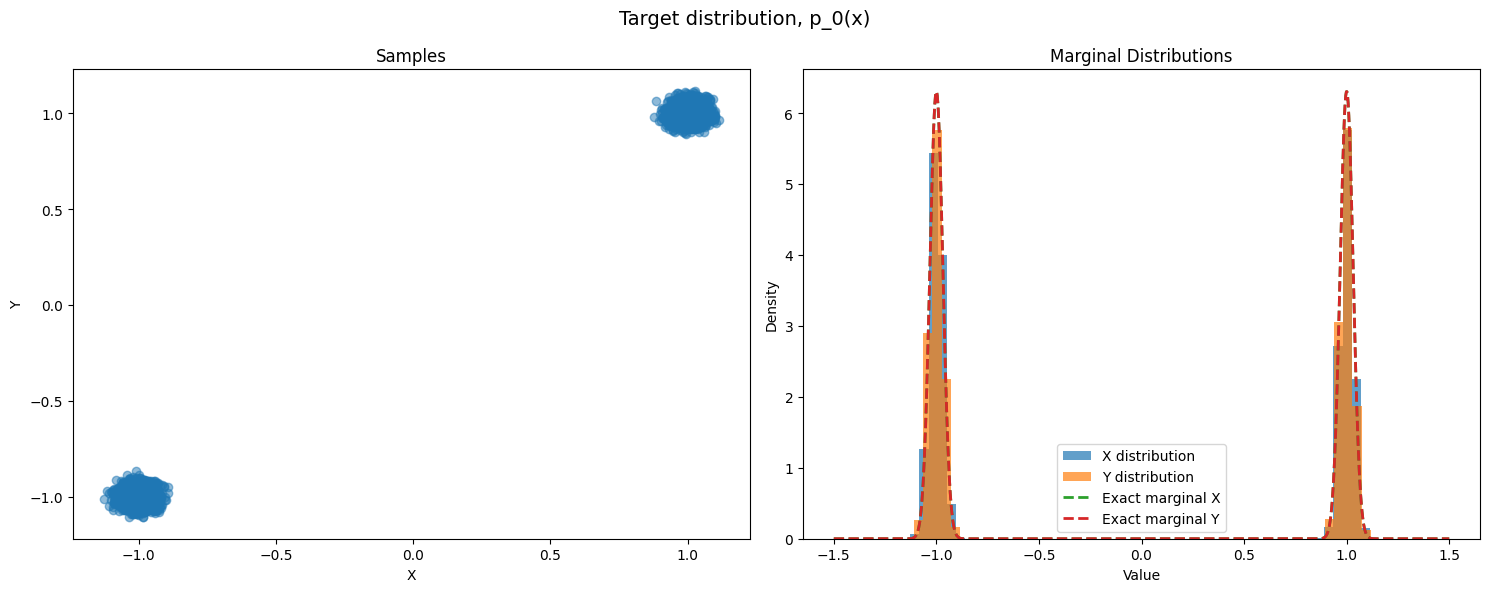

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
key, subkey = jr.split(key)
t_forward = 1.0
sigma_final = .1
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_final, samples0=samples_0, key=subkey)

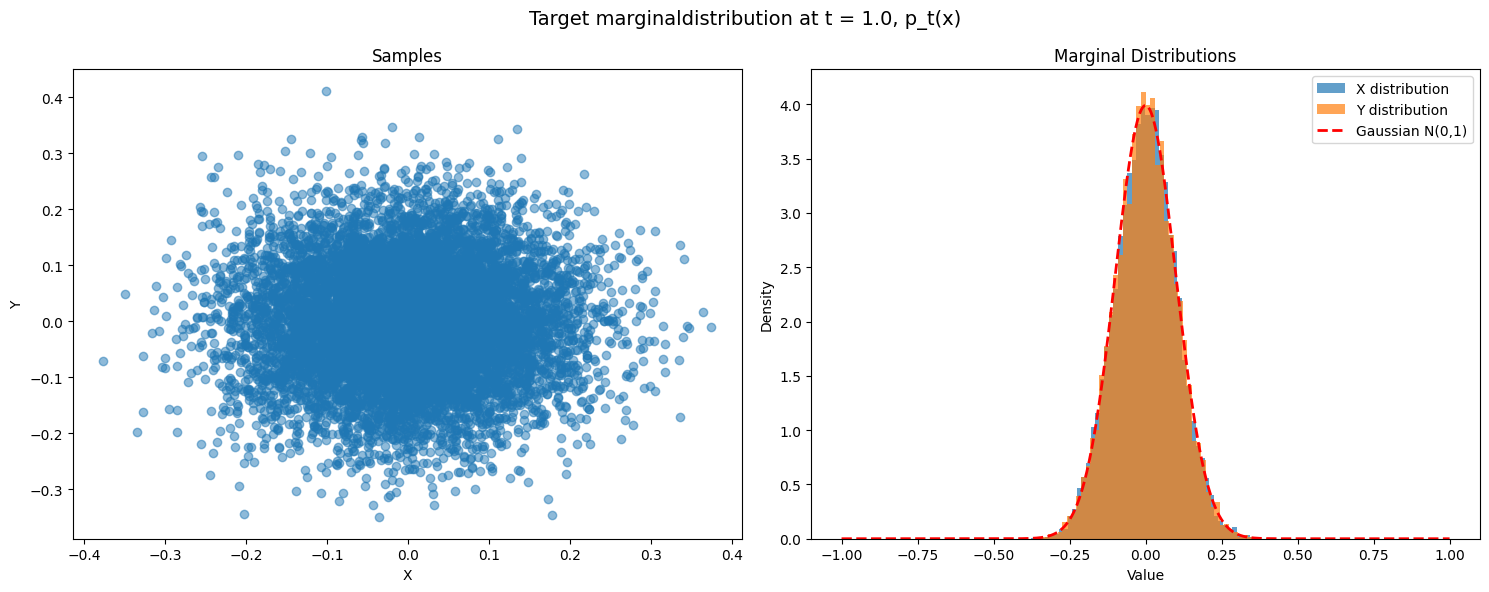

In [5]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Target marginaldistribution at t = {t_forward}, p_t(x)', fontsize=14)


# First subplot: Scatter plot of samples
ax1.scatter(samples_t[:, 0], samples_t[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_t[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_t[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add Gaussian N(0,1) for comparison
x = jnp.linspace(-1, 1, 1000)  # Adjust range as needed
gaussian_pdf = (1 / jnp.sqrt(2 * jnp.pi*sigma_final**2)) * jnp.exp(-0.5 * x**2/sigma_final**2)
ax2.plot(x, gaussian_pdf, 'r--', linewidth=2, label='Gaussian N(0,1)')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [6]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )


def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=1., T=1.):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [7]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 0.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

flattened_args_initial = jnp.array([-614.42648671,  588.10603632,  482.38294911, 1459.22532574,
         81.11413943,    0.        ])

args_initial = unflatten(flattened_args_initial)


### Bringe energy into correct form

In [8]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


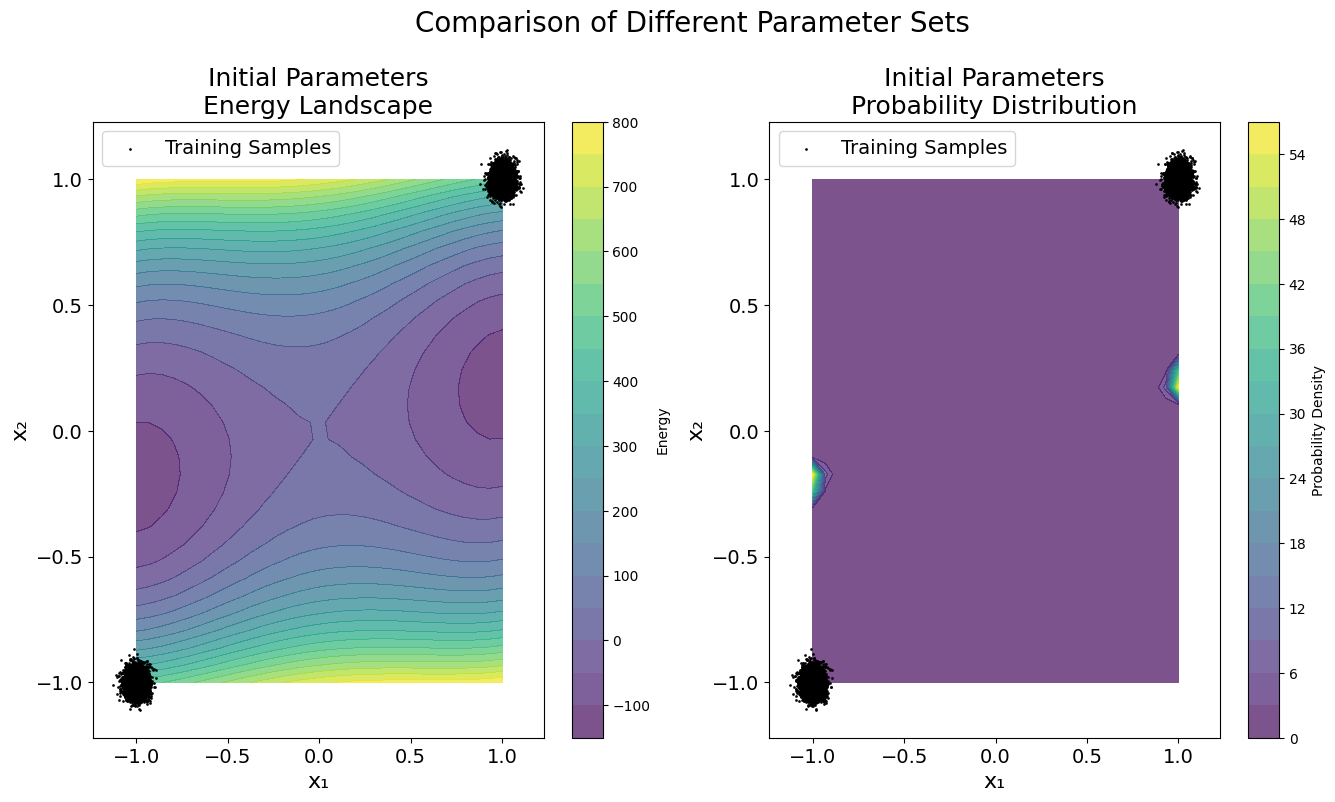

In [9]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets" 
)

In [10]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

In [11]:
# Define filename for saving/loading parameters
n_time_steps = 300
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-20), jnp.log(t_forward), n_time_steps))
# forward_time_pts = jnp.concatenate([jnp.array([0.]),forward_time_pts])

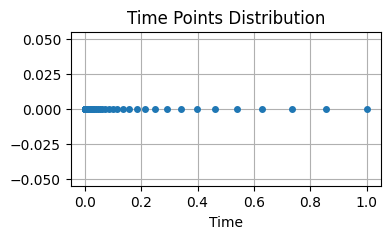

In [12]:
plt.figure(figsize=(4, 2))
plt.plot(forward_time_pts, jnp.zeros_like(forward_time_pts), 'o', markersize=4)
plt.xlabel('Time')
plt.ylabel('')
plt.title('Time Points Distribution')
plt.grid(True)
plt.show()

Optimization for time 9.999999999999992e-21 with num epochs: 50000
Epoch 0
Loss: 2132615.7446
---
Epoch 100
Loss: 2108011.5949
---
Epoch 200
Loss: 2049065.5039
---
Epoch 300
Loss: 1995037.8519
---
Epoch 400
Loss: 1968770.7741
---
Epoch 500
Loss: 1948100.8323
---
Epoch 600
Loss: 1860049.3182
---
Epoch 700
Loss: 1833281.2325
---
Epoch 800
Loss: 1797445.0628
---
Epoch 900
Loss: 1738435.7296
---
Epoch 1000
Loss: 1729276.6591
---
Epoch 1100
Loss: 1716485.8699
---
Epoch 1200
Loss: 1660786.2210
---
Epoch 1300
Loss: 1614010.2175
---
Epoch 1400
Loss: 1600720.1610
---
Epoch 1500
Loss: 1569735.9351
---
Epoch 1600
Loss: 1519791.8046
---
Epoch 1700
Loss: 1468055.8242
---
Epoch 1800
Loss: 1446388.0515
---
Epoch 1900
Loss: 1446427.6287
---
Epoch 2000
Loss: 1386283.3600
---
Epoch 2100
Loss: 1382833.5161
---
Epoch 2200
Loss: 1291043.4132
---
Epoch 2300
Loss: 1311185.1449
---
Epoch 2400
Loss: 1273926.5682
---
Epoch 2500
Loss: 1235682.6026
---
Epoch 2600
Loss: 1213613.6019
---
Epoch 2700
Loss: 1175367.25

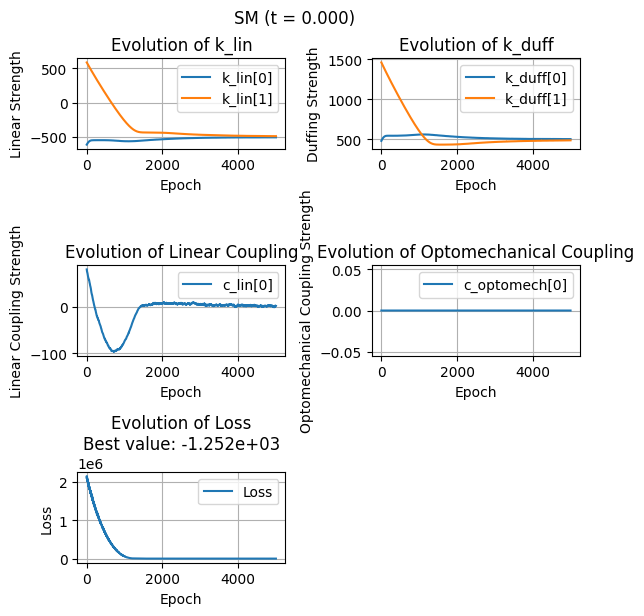

Optimization for time 1.1665131316981968e-20 with num epochs: 3000
Epoch 0
Loss: -985.2090
---
Epoch 100
Loss: -1025.3228
---
Epoch 200
Loss: -1098.5822
---
Epoch 300
Loss: -994.2493
---
Epoch 400
Loss: -878.1500
---
Epoch 500
Loss: -915.2180
---
Epoch 600
Loss: -947.9784
---
Epoch 700
Loss: -1035.5183
---
Epoch 800
Loss: -1020.6720
---
Epoch 900
Loss: -1176.7874
---
Epoch 1000
Loss: -931.8363
---
Epoch 1100
Loss: -995.3044
---
Epoch 1200
Loss: -1029.7710
---
Epoch 1300
Loss: -895.7392
---
Epoch 1400
Loss: -1063.9768
---
Epoch 1500
Loss: -975.9735
---
Epoch 1600
Loss: -942.9448
---
Epoch 1700
Loss: -1015.5782
---
Epoch 1800
Loss: -904.3839
---
Epoch 1900
Loss: -1058.0938
---
Epoch 2000
Loss: -835.9054
---
Epoch 2100
Loss: -1067.4354
---
Epoch 2200
Loss: -947.5206
---
Epoch 2300
Loss: -887.4442
---
Epoch 2400
Loss: -1027.8752
---
Epoch 2500
Loss: -1070.7532
---
Epoch 2600
Loss: -891.7447
---
Epoch 2700
Loss: -1119.3821
---
Epoch 2800
Loss: -905.9540
---
Epoch 2900
Loss: -875.8769
---
Op

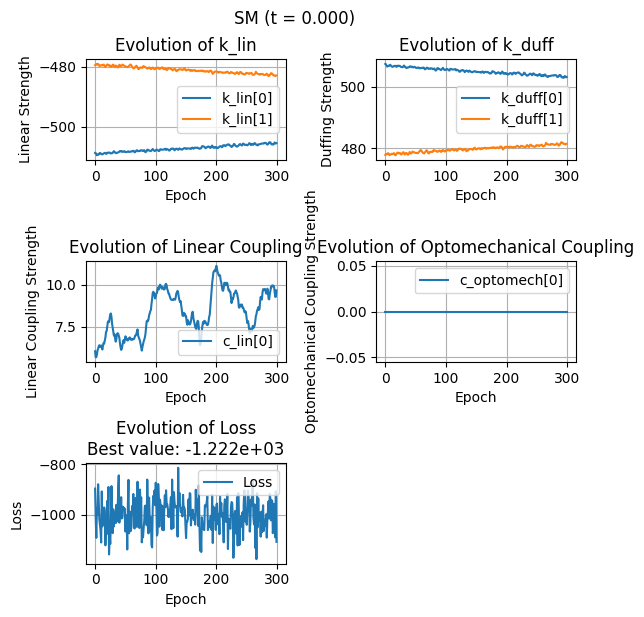

Optimization for time 5.442343548300262e-20 with num epochs: 3000
Epoch 0
Loss: -961.3657
---
Epoch 100
Loss: -1027.2371
---
Epoch 200
Loss: -1173.7023
---
Epoch 300
Loss: -1027.4799
---
Epoch 400
Loss: -1053.9581
---
Epoch 500
Loss: -1075.9856
---
Epoch 600
Loss: -890.2978
---
Epoch 700
Loss: -1021.6208
---
Epoch 800
Loss: -1085.5244
---
Epoch 900
Loss: -1045.0505
---
Epoch 1000
Loss: -1045.9562
---
Epoch 1100
Loss: -907.3430
---
Epoch 1200
Loss: -963.1869
---
Epoch 1300
Loss: -1008.1666
---
Epoch 1400
Loss: -1005.4190
---
Epoch 1500
Loss: -1016.4950
---
Epoch 1600
Loss: -1050.9179
---
Epoch 1700
Loss: -1097.8075
---
Epoch 1800
Loss: -998.0531
---
Epoch 1900
Loss: -1020.1015
---
Epoch 2000
Loss: -897.1521
---
Epoch 2100
Loss: -1034.0691
---
Epoch 2200
Loss: -1074.2597
---
Epoch 2300
Loss: -947.6113
---
Epoch 2400
Loss: -989.2213
---
Epoch 2500
Loss: -1039.7193
---
Epoch 2600
Loss: -1072.1007
---
Epoch 2700
Loss: -1080.1720
---
Epoch 2800
Loss: -1030.0978
---
Epoch 2900
Loss: -962.6606

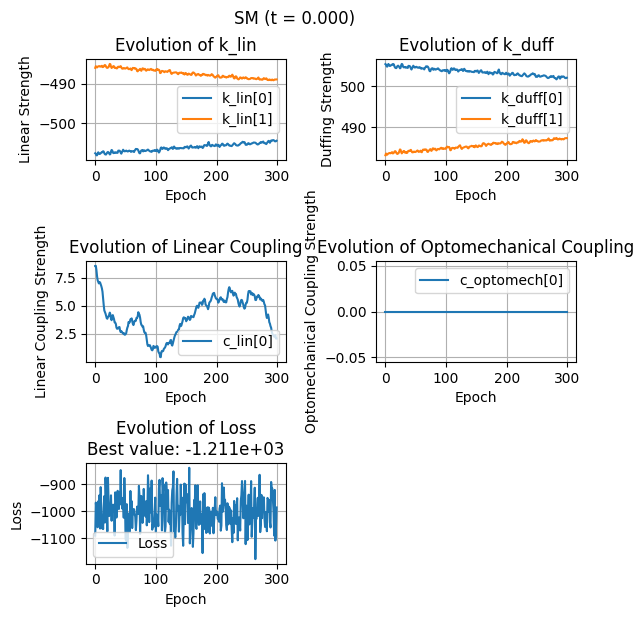

Optimization for time 2.539114433680342e-19 with num epochs: 3000
Epoch 0
Loss: -864.0740
---
Epoch 100
Loss: -986.5876
---
Epoch 200
Loss: -924.4848
---
Epoch 300
Loss: -964.8593
---
Epoch 400
Loss: -1011.1398
---
Epoch 500
Loss: -1056.5007
---
Epoch 600
Loss: -976.0118
---
Epoch 700
Loss: -1082.5155
---
Epoch 800
Loss: -991.3376
---
Epoch 900
Loss: -973.5195
---
Epoch 1000
Loss: -1059.0348
---
Epoch 1100
Loss: -902.2079
---
Epoch 1200
Loss: -1001.4979
---
Epoch 1300
Loss: -927.3497
---
Epoch 1400
Loss: -1102.1452
---
Epoch 1500
Loss: -1046.7263
---
Epoch 1600
Loss: -1071.6065
---
Epoch 1700
Loss: -874.6617
---
Epoch 1800
Loss: -1023.7428
---
Epoch 1900
Loss: -1078.9925
---
Epoch 2000
Loss: -948.1387
---
Epoch 2100
Loss: -1012.9932
---
Epoch 2200
Loss: -967.0528
---
Epoch 2300
Loss: -989.2441
---
Epoch 2400
Loss: -1015.0412
---
Epoch 2500
Loss: -1002.3247
---
Epoch 2600
Loss: -1026.8420
---
Epoch 2700
Loss: -1059.0352
---
Epoch 2800
Loss: -993.6638
---
Epoch 2900
Loss: -989.4011
---
O

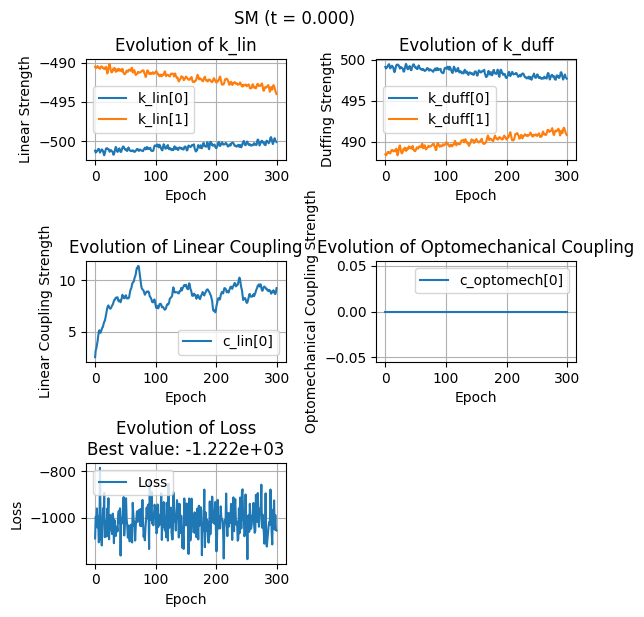

Optimization for time 1.184618730902688e-18 with num epochs: 3000
Epoch 0
Loss: -1019.5355
---
Epoch 100
Loss: -1025.3314
---
Epoch 200
Loss: -1038.1088
---
Epoch 300
Loss: -1018.0019
---
Epoch 400
Loss: -1081.5718
---
Epoch 500
Loss: -936.6549
---
Epoch 600
Loss: -1008.1912
---
Epoch 700
Loss: -1091.3917
---
Epoch 800
Loss: -920.1122
---
Epoch 900
Loss: -1020.3121
---
Epoch 1000
Loss: -968.6481
---
Epoch 1100
Loss: -1067.9055
---
Epoch 1200
Loss: -966.2101
---
Epoch 1300
Loss: -1031.9516
---
Epoch 1400
Loss: -1050.0850
---
Epoch 1500
Loss: -1042.2228
---
Epoch 1600
Loss: -939.8604
---
Epoch 1700
Loss: -1040.6135
---
Epoch 1800
Loss: -1028.4030
---
Epoch 1900
Loss: -953.1655
---
Epoch 2000
Loss: -951.5084
---
Epoch 2100
Loss: -993.2114
---
Epoch 2200
Loss: -874.0158
---
Epoch 2300
Loss: -1010.0416
---
Epoch 2400
Loss: -970.2642
---
Epoch 2500
Loss: -888.7650
---
Epoch 2600
Loss: -1107.2337
---
Epoch 2700
Loss: -1063.3887
---
Epoch 2800
Loss: -964.9259
---
Epoch 2900
Loss: -943.9241
---

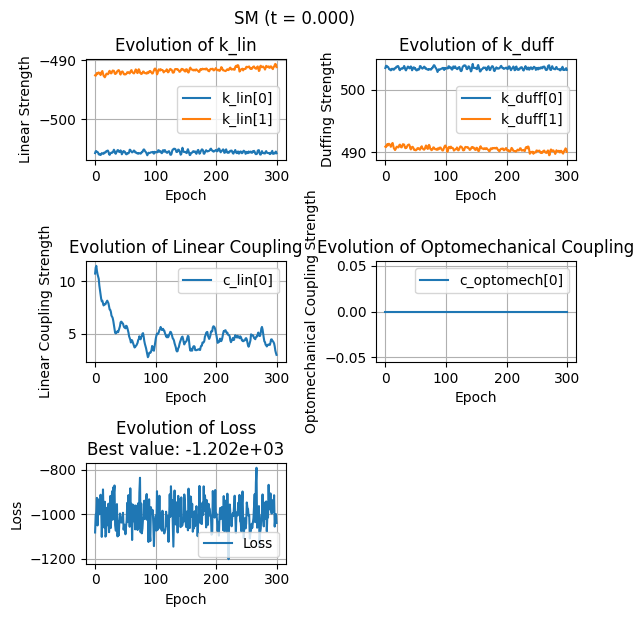

Optimization for time 5.526814857144616e-18 with num epochs: 3000
Epoch 0
Loss: -1013.7912
---
Epoch 100
Loss: -1075.6418
---
Epoch 200
Loss: -979.3201
---
Epoch 300
Loss: -987.5140
---
Epoch 400
Loss: -993.0465
---
Epoch 500
Loss: -948.2066
---
Epoch 600
Loss: -956.7093
---
Epoch 700
Loss: -1049.2950
---
Epoch 800
Loss: -999.3870
---
Epoch 900
Loss: -1118.5886
---
Epoch 1000
Loss: -1064.3754
---
Epoch 1100
Loss: -1032.1505
---
Epoch 1200
Loss: -989.5022
---
Epoch 1300
Loss: -1020.9320
---
Epoch 1400
Loss: -959.4400
---
Epoch 1500
Loss: -1017.7584
---
Epoch 1600
Loss: -911.9323
---
Epoch 1700
Loss: -921.8356
---
Epoch 1800
Loss: -919.7343
---
Epoch 1900
Loss: -1073.1852
---
Epoch 2000
Loss: -908.3265
---
Epoch 2100
Loss: -938.6748
---
Epoch 2200
Loss: -978.3535
---
Epoch 2300
Loss: -936.6068
---
Epoch 2400
Loss: -1133.2820
---
Epoch 2500
Loss: -926.0603
---
Epoch 2600
Loss: -1118.3849
---
Epoch 2700
Loss: -1154.1287
---
Epoch 2800
Loss: -932.7884
---
Epoch 2900
Loss: -1070.2476
---
Opt

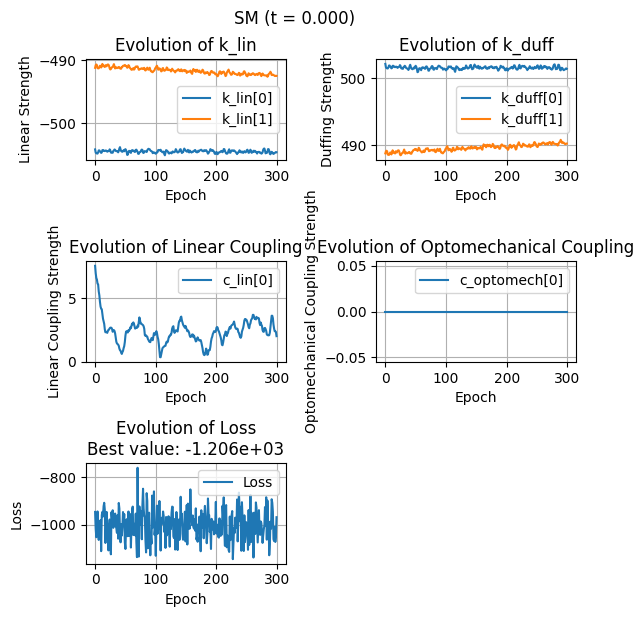

Optimization for time 2.5785243528842764e-17 with num epochs: 3000
Epoch 0
Loss: -880.9564
---
Epoch 100
Loss: -1034.3733
---
Epoch 200
Loss: -935.9136
---
Epoch 300
Loss: -988.5987
---
Epoch 400
Loss: -1050.1670
---
Epoch 500
Loss: -947.7186
---
Epoch 600
Loss: -978.8328
---
Epoch 700
Loss: -947.1522
---
Epoch 800
Loss: -1131.4208
---
Epoch 900
Loss: -1126.3048
---
Epoch 1000
Loss: -1014.4056
---
Epoch 1100
Loss: -1068.9071
---
Epoch 1200
Loss: -945.8086
---
Epoch 1300
Loss: -911.7967
---
Epoch 1400
Loss: -1039.2308
---
Epoch 1500
Loss: -1139.6674
---
Epoch 1600
Loss: -1049.5606
---
Epoch 1700
Loss: -999.0647
---
Epoch 1800
Loss: -1204.4311
---
Epoch 1900
Loss: -1052.7893
---
Epoch 2000
Loss: -1126.2211
---
Epoch 2100
Loss: -1088.6244
---
Epoch 2200
Loss: -911.4957
---
Epoch 2300
Loss: -1006.8163
---
Epoch 2400
Loss: -977.5730
---
Epoch 2500
Loss: -1000.7066
---
Epoch 2600
Loss: -982.7281
---
Epoch 2700
Loss: -1090.1090
---
Epoch 2800
Loss: -1120.0014
---
Epoch 2900
Loss: -1056.7490
-

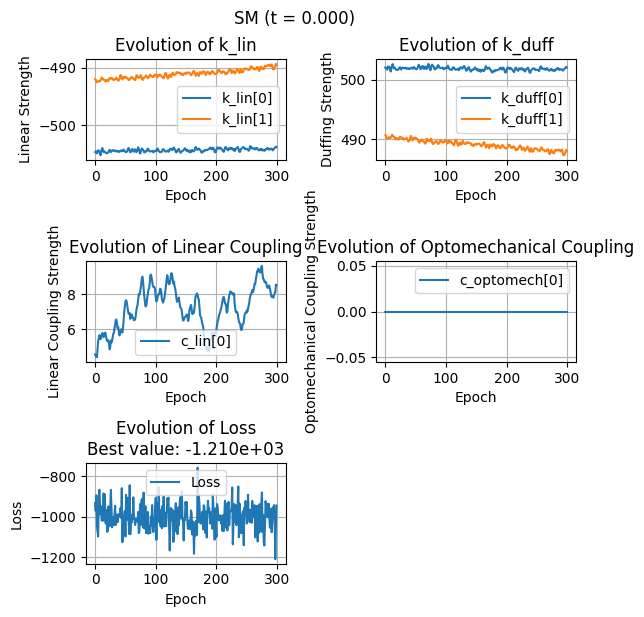

Optimization for time 1.2030053494233237e-16 with num epochs: 3000
Epoch 0
Loss: -1053.0910
---
Epoch 100
Loss: -942.7517
---
Epoch 200
Loss: -898.4813
---
Epoch 300
Loss: -1042.0679
---
Epoch 400
Loss: -969.7200
---
Epoch 500
Loss: -1051.2611
---
Epoch 600
Loss: -1091.4596
---
Epoch 700
Loss: -973.8067
---
Epoch 800
Loss: -1061.8158
---
Epoch 900
Loss: -969.9881
---
Epoch 1000
Loss: -1076.8627
---
Epoch 1100
Loss: -1075.3092
---
Epoch 1200
Loss: -1105.4481
---
Epoch 1300
Loss: -957.0070
---
Epoch 1400
Loss: -1078.2900
---
Epoch 1500
Loss: -1088.5191
---
Epoch 1600
Loss: -995.5738
---
Epoch 1700
Loss: -1094.9834
---
Epoch 1800
Loss: -1028.7775
---
Epoch 1900
Loss: -1014.3688
---
Epoch 2000
Loss: -985.1963
---
Epoch 2100
Loss: -1001.5972
---
Epoch 2200
Loss: -1080.5258
---
Epoch 2300
Loss: -1018.1194
---
Epoch 2400
Loss: -1068.9295
---
Epoch 2500
Loss: -979.6498
---
Epoch 2600
Loss: -1007.9055
---
Epoch 2700
Loss: -1030.5722
---
Epoch 2800
Loss: -973.9197
---
Epoch 2900
Loss: -897.3852


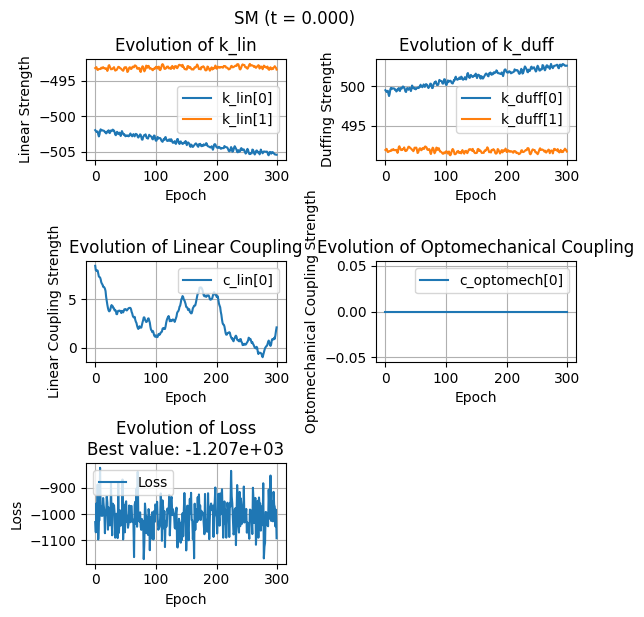

Optimization for time 5.612597255954962e-16 with num epochs: 3000
Epoch 0
Loss: -1109.5804
---
Epoch 100
Loss: -1116.9766
---
Epoch 200
Loss: -1108.1447
---
Epoch 300
Loss: -1115.0555
---
Epoch 400
Loss: -1067.3362
---
Epoch 500
Loss: -1100.8978
---
Epoch 600
Loss: -1117.4101
---
Epoch 700
Loss: -1033.3286
---
Epoch 800
Loss: -1032.9704
---
Epoch 900
Loss: -954.3053
---
Epoch 1000
Loss: -982.6340
---
Epoch 1100
Loss: -1087.9048
---
Epoch 1200
Loss: -1000.0682
---
Epoch 1300
Loss: -1061.6712
---
Epoch 1400
Loss: -822.5806
---
Epoch 1500
Loss: -1142.2089
---
Epoch 1600
Loss: -923.6171
---
Epoch 1700
Loss: -1099.6346
---
Epoch 1800
Loss: -1019.6720
---
Epoch 1900
Loss: -1010.1578
---
Epoch 2000
Loss: -1072.5442
---
Epoch 2100
Loss: -1080.3942
---
Epoch 2200
Loss: -1073.0609
---
Epoch 2300
Loss: -1046.2400
---
Epoch 2400
Loss: -1057.9023
---
Epoch 2500
Loss: -893.5416
---
Epoch 2600
Loss: -985.5723
---
Epoch 2700
Loss: -966.0329
---
Epoch 2800
Loss: -974.5126
---
Epoch 2900
Loss: -1119.601

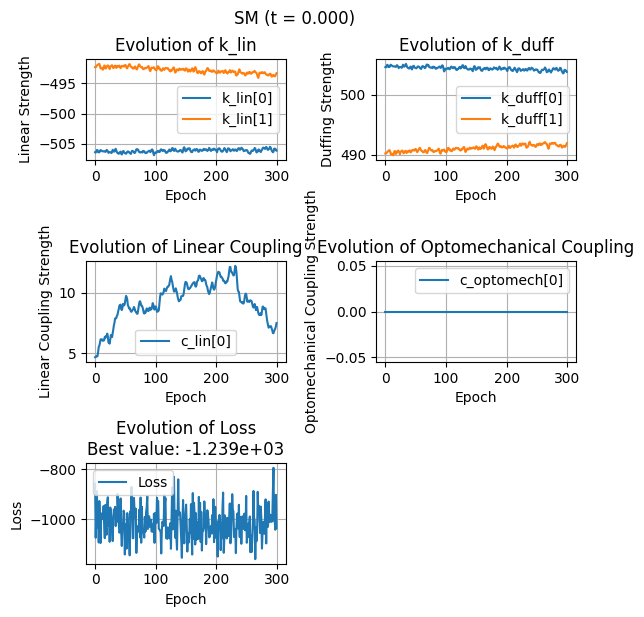

Optimization for time 2.618545958474243e-15 with num epochs: 3000
Epoch 0
Loss: -1006.2919
---
Epoch 100
Loss: -1048.1092
---
Epoch 200
Loss: -978.6943
---
Epoch 300
Loss: -1033.2822
---
Epoch 400
Loss: -970.0033
---
Epoch 500
Loss: -1052.5169
---
Epoch 600
Loss: -996.1939
---
Epoch 700
Loss: -989.8668
---
Epoch 800
Loss: -1020.7244
---
Epoch 900
Loss: -1044.0409
---
Epoch 1000
Loss: -1125.2313
---
Epoch 1100
Loss: -1131.3750
---
Epoch 1200
Loss: -1009.6246
---
Epoch 1300
Loss: -903.7643
---
Epoch 1400
Loss: -948.2526
---
Epoch 1500
Loss: -959.7310
---
Epoch 1600
Loss: -1096.3524
---
Epoch 1700
Loss: -897.7626
---
Epoch 1800
Loss: -891.9683
---
Epoch 1900
Loss: -1089.9550
---
Epoch 2000
Loss: -974.1889
---
Epoch 2100
Loss: -1085.8335
---
Epoch 2200
Loss: -1099.0130
---
Epoch 2300
Loss: -1058.7383
---
Epoch 2400
Loss: -1100.9982
---
Epoch 2500
Loss: -1003.8429
---
Epoch 2600
Loss: -978.9578
---
Epoch 2700
Loss: -1029.3868
---
Epoch 2800
Loss: -1054.9908
---
Epoch 2900
Loss: -1048.9925
-

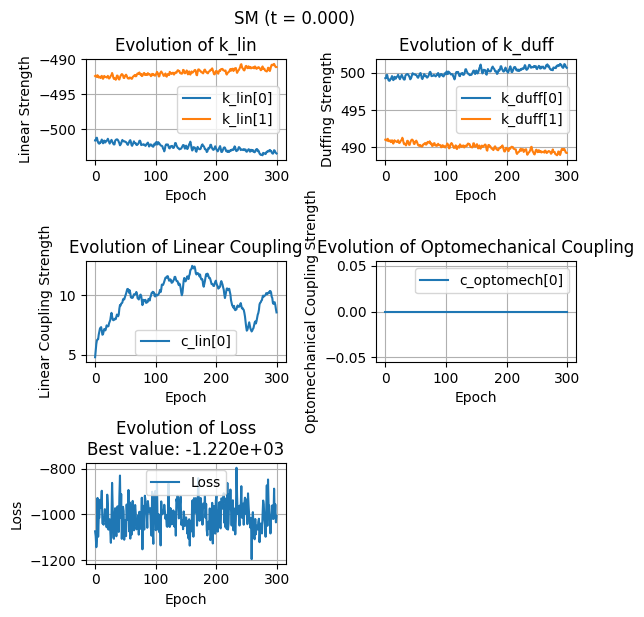

Optimization for time 1.2216773489967951e-14 with num epochs: 3000
Epoch 0
Loss: -951.3865
---
Epoch 100
Loss: -1058.8187
---
Epoch 200
Loss: -966.7665
---
Epoch 300
Loss: -1026.1782
---
Epoch 400
Loss: -1155.8418
---
Epoch 500
Loss: -1092.5652
---
Epoch 600
Loss: -964.0078
---
Epoch 700
Loss: -1003.1735
---
Epoch 800
Loss: -1088.0233
---
Epoch 900
Loss: -987.0639
---
Epoch 1000
Loss: -1016.0369
---
Epoch 1100
Loss: -1014.6469
---
Epoch 1200
Loss: -1089.2934
---
Epoch 1300
Loss: -980.0193
---
Epoch 1400
Loss: -1058.7287
---
Epoch 1500
Loss: -1062.0814
---
Epoch 1600
Loss: -928.0011
---
Epoch 1700
Loss: -991.2079
---
Epoch 1800
Loss: -1016.1472
---
Epoch 1900
Loss: -1048.6211
---
Epoch 2000
Loss: -1144.6068
---
Epoch 2100
Loss: -1012.1206
---
Epoch 2200
Loss: -1073.2193
---
Epoch 2300
Loss: -1041.9375
---
Epoch 2400
Loss: -1005.9748
---
Epoch 2500
Loss: -1006.7925
---
Epoch 2600
Loss: -1050.5977
---
Epoch 2700
Loss: -972.8040
---
Epoch 2800
Loss: -1026.0538
---
Epoch 2900
Loss: -913.072

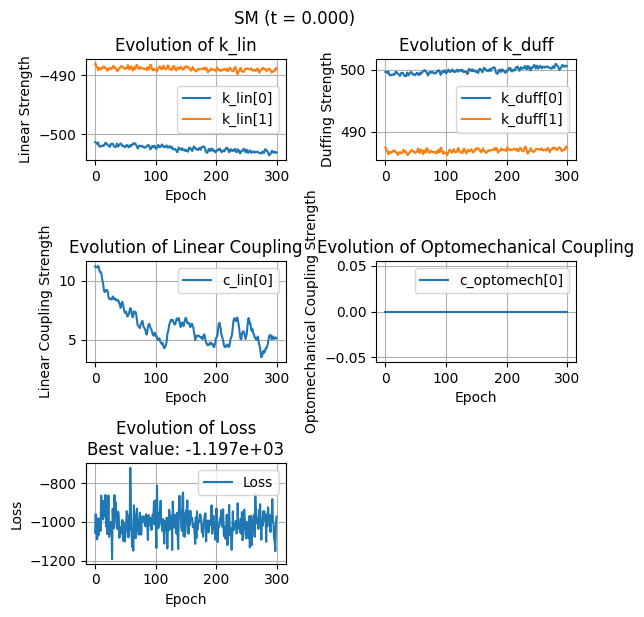

Optimization for time 5.699711094326062e-14 with num epochs: 3000
Epoch 0
Loss: -1071.3926
---
Epoch 100
Loss: -1017.9816
---
Epoch 200
Loss: -1012.2976
---
Epoch 300
Loss: -973.3234
---
Epoch 400
Loss: -1050.9377
---
Epoch 500
Loss: -1097.2447
---
Epoch 600
Loss: -882.1713
---
Epoch 700
Loss: -1042.2416
---
Epoch 800
Loss: -1015.1453
---
Epoch 900
Loss: -924.4515
---
Epoch 1000
Loss: -909.7514
---
Epoch 1100
Loss: -1017.1218
---
Epoch 1200
Loss: -1074.4925
---
Epoch 1300
Loss: -910.3889
---
Epoch 1400
Loss: -988.3870
---
Epoch 1500
Loss: -1047.9145
---
Epoch 1600
Loss: -1031.4442
---
Epoch 1700
Loss: -903.0445
---
Epoch 1800
Loss: -880.1479
---
Epoch 1900
Loss: -1054.1691
---
Epoch 2000
Loss: -930.2786
---
Epoch 2100
Loss: -1060.6176
---
Epoch 2200
Loss: -939.1073
---
Epoch 2300
Loss: -1007.7919
---
Epoch 2400
Loss: -914.4209
---
Epoch 2500
Loss: -1050.9798
---
Epoch 2600
Loss: -1001.2419
---
Epoch 2700
Loss: -1047.2996
---
Epoch 2800
Loss: -994.6435
---
Epoch 2900
Loss: -1054.1125
--

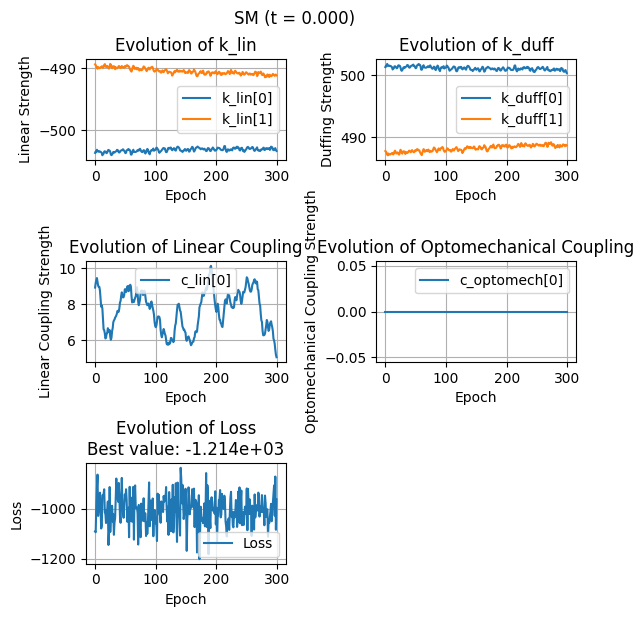

Optimization for time 2.6591887445126936e-13 with num epochs: 3000
Epoch 0
Loss: -951.8722
---
Epoch 100
Loss: -1074.5438
---
Epoch 200
Loss: -877.9939
---
Epoch 300
Loss: -1143.5329
---
Epoch 400
Loss: -986.5011
---
Epoch 500
Loss: -980.6750
---
Epoch 600
Loss: -1009.4287
---
Epoch 700
Loss: -1207.1566
---
Epoch 800
Loss: -1044.9569
---
Epoch 900
Loss: -952.3612
---
Epoch 1000
Loss: -963.9502
---
Epoch 1100
Loss: -1086.3385
---
Epoch 1200
Loss: -977.3804
---
Epoch 1300
Loss: -941.6126
---
Epoch 1400
Loss: -1086.8328
---
Epoch 1500
Loss: -1049.1929
---
Epoch 1600
Loss: -925.4434
---
Epoch 1700
Loss: -1000.9027
---
Epoch 1800
Loss: -931.0348
---
Epoch 1900
Loss: -960.5615
---
Epoch 2000
Loss: -1100.9969
---
Epoch 2100
Loss: -980.9138
---
Epoch 2200
Loss: -954.1235
---
Epoch 2300
Loss: -1112.8774
---
Epoch 2400
Loss: -1087.3570
---
Epoch 2500
Loss: -1035.8554
---
Epoch 2600
Loss: -1049.8768
---
Epoch 2700
Loss: -1012.5267
---
Epoch 2800
Loss: -1073.7794
---
Epoch 2900
Loss: -1008.2622
--

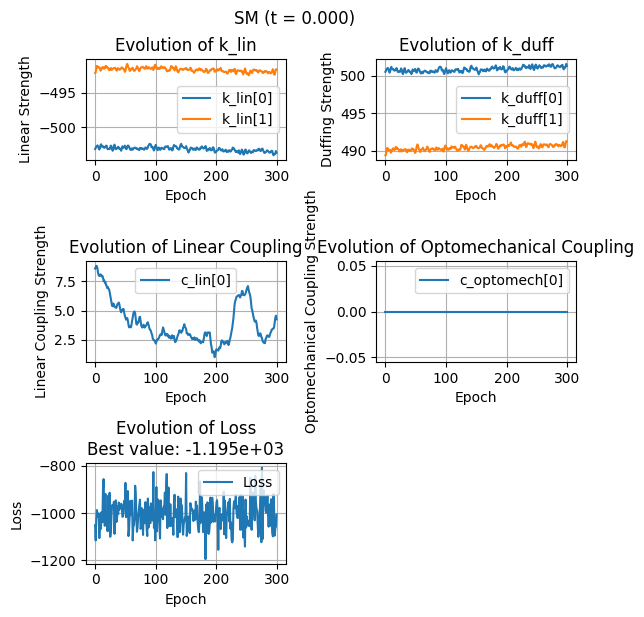

Optimization for time 1.24063915905883e-12 with num epochs: 3000
Epoch 0
Loss: -1032.2789
---
Epoch 100
Loss: -975.5552
---
Epoch 200
Loss: -1124.5372
---
Epoch 300
Loss: -1126.2731
---
Epoch 400
Loss: -1015.7062
---
Epoch 500
Loss: -956.8380
---
Epoch 600
Loss: -1119.6426
---
Epoch 700
Loss: -967.8331
---
Epoch 800
Loss: -885.5063
---
Epoch 900
Loss: -1049.1660
---
Epoch 1000
Loss: -1036.7297
---
Epoch 1100
Loss: -1062.6165
---
Epoch 1200
Loss: -981.7363
---
Epoch 1300
Loss: -990.8906
---
Epoch 1400
Loss: -991.4802
---
Epoch 1500
Loss: -1101.6257
---
Epoch 1600
Loss: -931.5505
---
Epoch 1700
Loss: -1064.9352
---
Epoch 1800
Loss: -972.8540
---
Epoch 1900
Loss: -1022.8468
---
Epoch 2000
Loss: -1097.5151
---
Epoch 2100
Loss: -1083.6068
---
Epoch 2200
Loss: -997.6146
---
Epoch 2300
Loss: -994.4886
---
Epoch 2400
Loss: -1006.1677
---
Epoch 2500
Loss: -1092.1959
---
Epoch 2600
Loss: -1047.4618
---
Epoch 2700
Loss: -1090.3240
---
Epoch 2800
Loss: -1061.1498
---
Epoch 2900
Loss: -909.8364
---

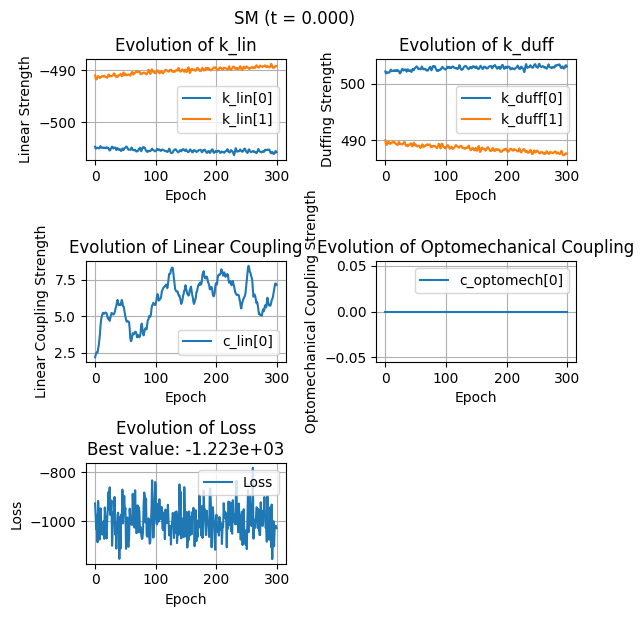

Optimization for time 5.788177037701279e-12 with num epochs: 3000
Epoch 0
Loss: -949.2400
---
Epoch 100
Loss: -969.3565
---
Epoch 200
Loss: -866.1412
---
Epoch 300
Loss: -1019.8889
---
Epoch 400
Loss: -996.0803
---
Epoch 500
Loss: -920.2099
---
Epoch 600
Loss: -999.5304
---
Epoch 700
Loss: -842.9663
---
Epoch 800
Loss: -904.9227
---
Epoch 900
Loss: -1070.1478
---
Epoch 1000
Loss: -1033.4040
---
Epoch 1100
Loss: -1034.0795
---
Epoch 1200
Loss: -947.4879
---
Epoch 1300
Loss: -946.6720
---
Epoch 1400
Loss: -904.1790
---
Epoch 1500
Loss: -1083.2046
---
Epoch 1600
Loss: -990.1681
---
Epoch 1700
Loss: -994.6919
---
Epoch 1800
Loss: -1014.1405
---
Epoch 1900
Loss: -1062.7264
---
Epoch 2000
Loss: -988.7960
---
Epoch 2100
Loss: -1002.6176
---
Epoch 2200
Loss: -984.6798
---
Epoch 2300
Loss: -1032.8977
---
Epoch 2400
Loss: -1014.4415
---
Epoch 2500
Loss: -898.7202
---
Epoch 2600
Loss: -1017.2180
---
Epoch 2700
Loss: -923.6493
---
Epoch 2800
Loss: -958.4535
---
Epoch 2900
Loss: -1141.2346
---
Opti

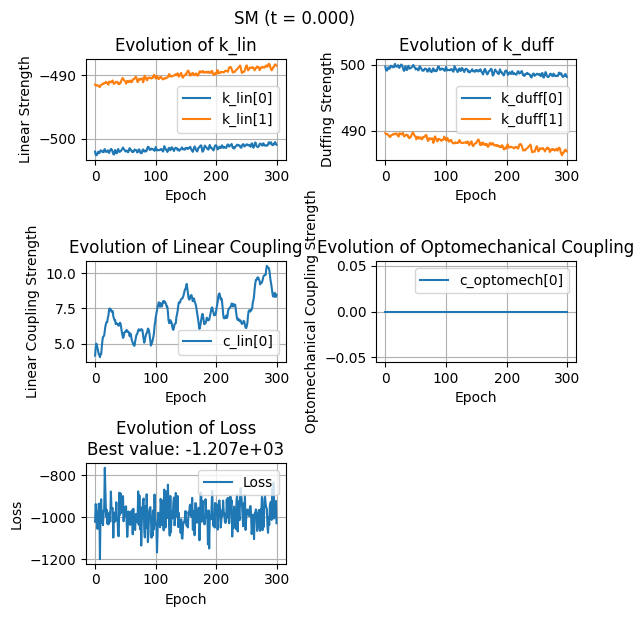

Optimization for time 2.7004623524206808e-11 with num epochs: 3000
Epoch 0
Loss: -1055.8572
---
Epoch 100
Loss: -918.5218
---
Epoch 200
Loss: -988.3711
---
Epoch 300
Loss: -976.1411
---
Epoch 400
Loss: -964.0735
---
Epoch 500
Loss: -1030.9482
---
Epoch 600
Loss: -1148.1914
---
Epoch 700
Loss: -1001.3462
---
Epoch 800
Loss: -977.3319
---
Epoch 900
Loss: -1037.8389
---
Epoch 1000
Loss: -970.7472
---
Epoch 1100
Loss: -843.9796
---
Epoch 1200
Loss: -941.9909
---
Epoch 1300
Loss: -1028.1992
---
Epoch 1400
Loss: -983.2230
---
Epoch 1500
Loss: -1024.5847
---
Epoch 1600
Loss: -996.1430
---
Epoch 1700
Loss: -919.2864
---
Epoch 1800
Loss: -990.8026
---
Epoch 1900
Loss: -1105.5832
---
Epoch 2000
Loss: -993.8747
---
Epoch 2100
Loss: -944.1063
---
Epoch 2200
Loss: -1046.0546
---
Epoch 2300
Loss: -964.3337
---
Epoch 2400
Loss: -915.8357
---
Epoch 2500
Loss: -1019.9166
---
Epoch 2600
Loss: -925.2850
---
Epoch 2700
Loss: -829.4313
---
Epoch 2800
Loss: -1011.7717
---
Epoch 2900
Loss: -931.1945
---
Opti

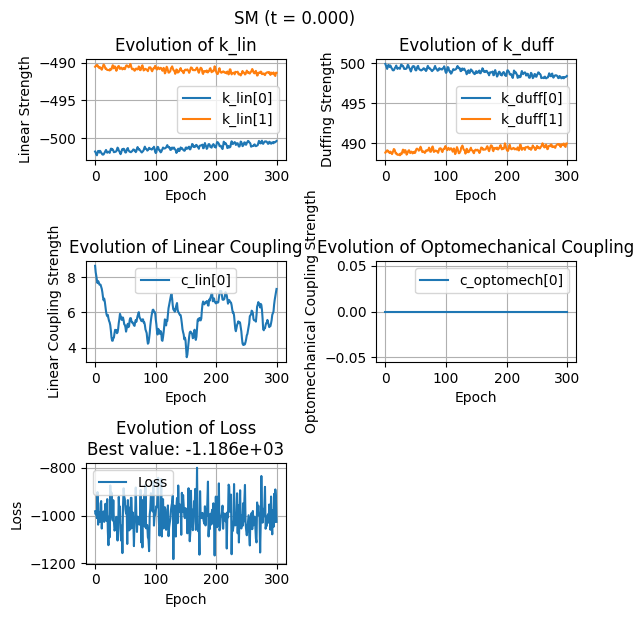

Optimization for time 1.2598952777950248e-10 with num epochs: 3000
Epoch 0
Loss: -1081.6339
---
Epoch 100
Loss: -1100.0241
---
Epoch 200
Loss: -1020.9584
---
Epoch 300
Loss: -984.3770
---
Epoch 400
Loss: -1036.9377
---
Epoch 500
Loss: -1006.9922
---
Epoch 600
Loss: -1028.8955
---
Epoch 700
Loss: -1060.6088
---
Epoch 800
Loss: -929.8005
---
Epoch 900
Loss: -1156.7422
---
Epoch 1000
Loss: -970.7339
---
Epoch 1100
Loss: -1057.1575
---
Epoch 1200
Loss: -1017.1784
---
Epoch 1300
Loss: -979.1585
---
Epoch 1400
Loss: -906.4434
---
Epoch 1500
Loss: -1137.0338
---
Epoch 1600
Loss: -892.3623
---
Epoch 1700
Loss: -1026.8849
---
Epoch 1800
Loss: -801.7916
---
Epoch 1900
Loss: -1012.5583
---
Epoch 2000
Loss: -995.0891
---
Epoch 2100
Loss: -1007.9498
---
Epoch 2200
Loss: -1131.9701
---
Epoch 2300
Loss: -1008.8583
---
Epoch 2400
Loss: -1021.6515
---
Epoch 2500
Loss: -878.0358
---
Epoch 2600
Loss: -987.0100
---
Epoch 2700
Loss: -1023.8031
---
Epoch 2800
Loss: -910.9388
---
Epoch 2900
Loss: -911.5017
-

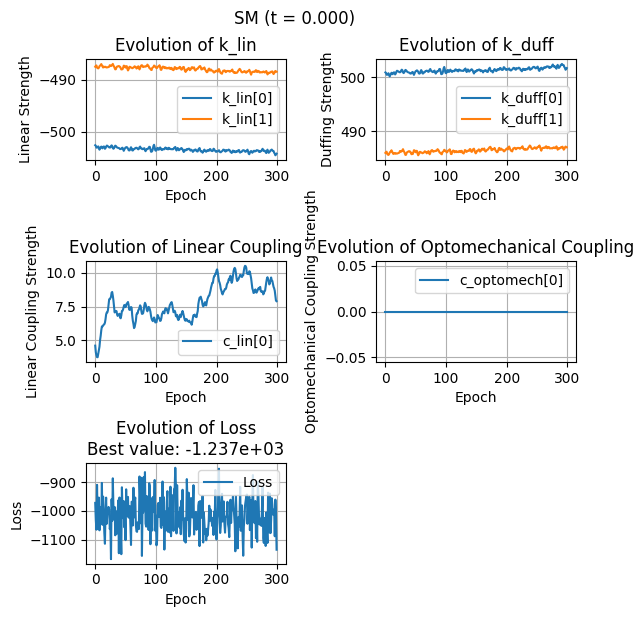

Optimization for time 5.878016072274914e-10 with num epochs: 3000
Epoch 0
Loss: -1046.7180
---
Epoch 100
Loss: -961.3684
---
Epoch 200
Loss: -999.1860
---
Epoch 300
Loss: -1048.5714
---
Epoch 400
Loss: -921.7945
---
Epoch 500
Loss: -904.1081
---
Epoch 600
Loss: -1105.4620
---
Epoch 700
Loss: -928.4213
---
Epoch 800
Loss: -950.0373
---
Epoch 900
Loss: -1045.7843
---
Epoch 1000
Loss: -995.1814
---
Epoch 1100
Loss: -1044.0724
---
Epoch 1200
Loss: -1016.9793
---
Epoch 1300
Loss: -953.7571
---
Epoch 1400
Loss: -984.7717
---
Epoch 1500
Loss: -1018.6536
---
Epoch 1600
Loss: -1132.9378
---
Epoch 1700
Loss: -1008.1013
---
Epoch 1800
Loss: -1051.2402
---
Epoch 1900
Loss: -924.6620
---
Epoch 2000
Loss: -1005.0288
---
Epoch 2100
Loss: -1084.5784
---
Epoch 2200
Loss: -1017.0874
---
Epoch 2300
Loss: -1057.7427
---
Epoch 2400
Loss: -1069.1930
---
Epoch 2500
Loss: -970.0129
---
Epoch 2600
Loss: -942.2102
---
Epoch 2700
Loss: -951.9787
---
Epoch 2800
Loss: -984.6610
---
Epoch 2900
Loss: -944.1981
---
O

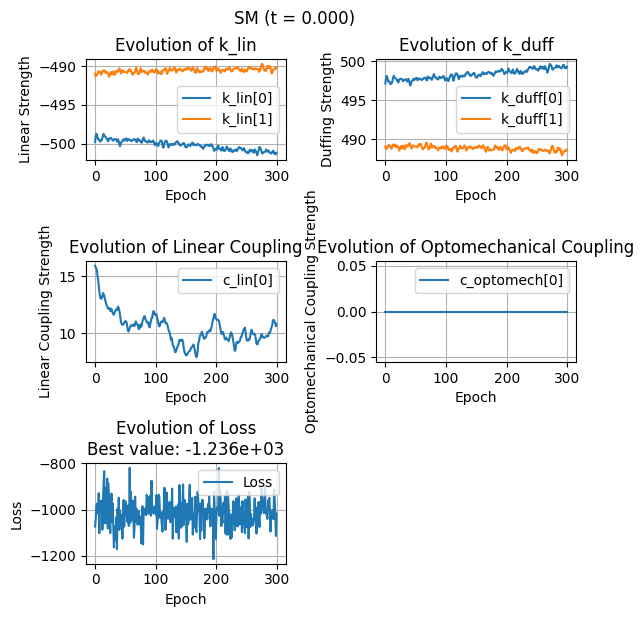

Optimization for time 2.742376573264947e-09 with num epochs: 3000
Epoch 0
Loss: -1007.9665
---
Epoch 100
Loss: -875.5606
---
Epoch 200
Loss: -1009.9594
---
Epoch 300
Loss: -1025.4590
---
Epoch 400
Loss: -827.8596
---
Epoch 500
Loss: -1049.5869
---
Epoch 600
Loss: -1055.0253
---
Epoch 700
Loss: -870.2529
---
Epoch 800
Loss: -806.4802
---
Epoch 900
Loss: -952.0171
---
Epoch 1000
Loss: -1010.4499
---
Epoch 1100
Loss: -958.7419
---
Epoch 1200
Loss: -962.8784
---
Epoch 1300
Loss: -1042.9366
---
Epoch 1400
Loss: -1087.5413
---
Epoch 1500
Loss: -977.5398
---
Epoch 1600
Loss: -998.5055
---
Epoch 1700
Loss: -1008.0587
---
Epoch 1800
Loss: -1012.0334
---
Epoch 1900
Loss: -1058.4799
---
Epoch 2000
Loss: -922.8043
---
Epoch 2100
Loss: -996.7428
---
Epoch 2200
Loss: -1168.2220
---
Epoch 2300
Loss: -1002.5589
---
Epoch 2400
Loss: -902.7690
---
Epoch 2500
Loss: -1103.5699
---
Epoch 2600
Loss: -827.9132
---
Epoch 2700
Loss: -901.3754
---
Epoch 2800
Loss: -1010.8793
---
Epoch 2900
Loss: -935.6106
---
O

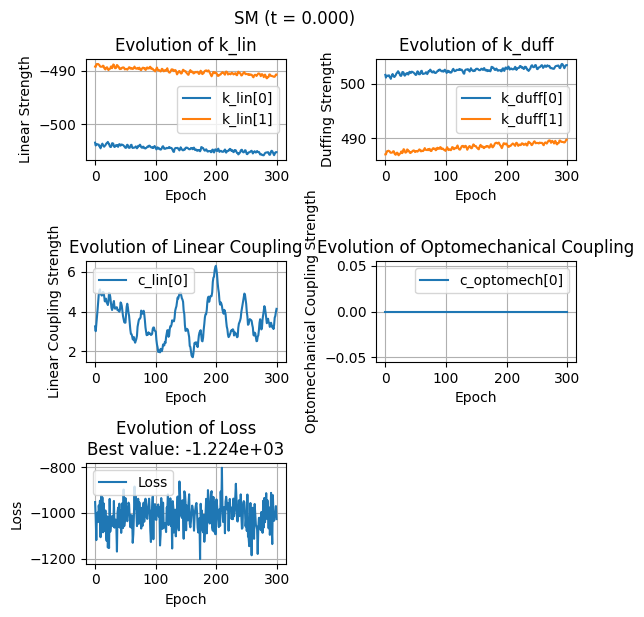

Optimization for time 1.2794502732078704e-08 with num epochs: 3000
Epoch 0
Loss: -1045.1667
---
Epoch 100
Loss: -1032.6769
---
Epoch 200
Loss: -993.1302
---
Epoch 300
Loss: -1099.4087
---
Epoch 400
Loss: -932.2418
---
Epoch 500
Loss: -1073.9804
---
Epoch 600
Loss: -981.6105
---
Epoch 700
Loss: -1100.7819
---
Epoch 800
Loss: -1085.2399
---
Epoch 900
Loss: -1029.8427
---
Epoch 1000
Loss: -1039.6290
---
Epoch 1100
Loss: -989.0120
---
Epoch 1200
Loss: -1102.9377
---
Epoch 1300
Loss: -981.0848
---
Epoch 1400
Loss: -1117.4379
---
Epoch 1500
Loss: -947.9435
---
Epoch 1600
Loss: -975.6322
---
Epoch 1700
Loss: -1001.7804
---
Epoch 1800
Loss: -1032.0174
---
Epoch 1900
Loss: -1060.7945
---
Epoch 2000
Loss: -1003.5737
---
Epoch 2100
Loss: -1109.1199
---
Epoch 2200
Loss: -896.3653
---
Epoch 2300
Loss: -986.8216
---
Epoch 2400
Loss: -1110.1861
---
Epoch 2500
Loss: -946.3335
---
Epoch 2600
Loss: -1028.6183
---
Epoch 2700
Loss: -980.3671
---
Epoch 2800
Loss: -1059.6015
---
Epoch 2900
Loss: -978.7301
-

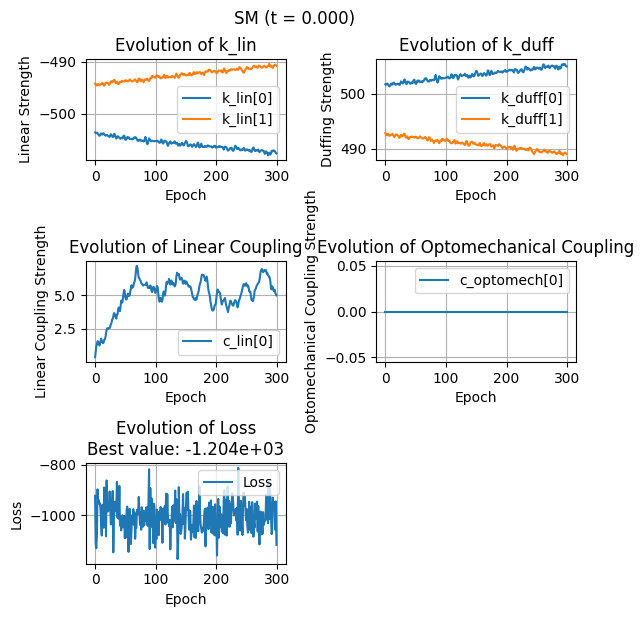

Optimization for time 5.969249509970733e-08 with num epochs: 3000
Epoch 0
Loss: -1026.8235
---
Epoch 100
Loss: -917.2394
---
Epoch 200
Loss: -964.9084
---
Epoch 300
Loss: -1053.7052
---
Epoch 400
Loss: -985.5998
---
Epoch 500
Loss: -940.8866
---
Epoch 600
Loss: -945.6953
---
Epoch 700
Loss: -875.7761
---
Epoch 800
Loss: -938.9037
---
Epoch 900
Loss: -1026.0876
---
Epoch 1000
Loss: -1027.5744
---
Epoch 1100
Loss: -1059.6360
---
Epoch 1200
Loss: -969.6393
---
Epoch 1300
Loss: -886.3493
---
Epoch 1400
Loss: -998.0905
---
Epoch 1500
Loss: -1010.1934
---
Epoch 1600
Loss: -1040.0874
---
Epoch 1700
Loss: -869.8256
---
Epoch 1800
Loss: -1031.6423
---
Epoch 1900
Loss: -933.6800
---
Epoch 2000
Loss: -951.7048
---
Epoch 2100
Loss: -1039.2673
---
Epoch 2200
Loss: -1023.9787
---
Epoch 2300
Loss: -1073.0248
---
Epoch 2400
Loss: -917.6351
---
Epoch 2500
Loss: -960.9791
---
Epoch 2600
Loss: -1158.0014
---
Epoch 2700
Loss: -904.2771
---
Epoch 2800
Loss: -1003.4972
---
Epoch 2900
Loss: -1065.0625
---
Op

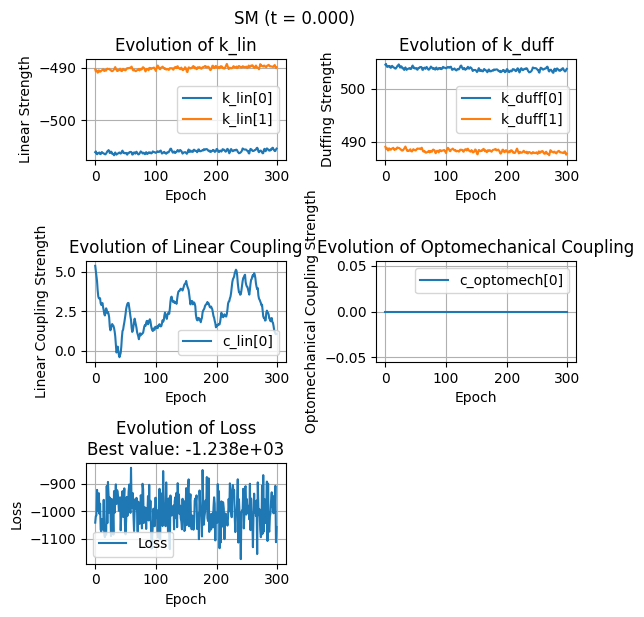

Optimization for time 2.784941350080645e-07 with num epochs: 3000
Epoch 0
Loss: -981.0205
---
Epoch 100
Loss: -1054.4641
---
Epoch 200
Loss: -898.9574
---
Epoch 300
Loss: -975.2880
---
Epoch 400
Loss: -1103.3959
---
Epoch 500
Loss: -920.8595
---
Epoch 600
Loss: -1048.9962
---
Epoch 700
Loss: -969.8779
---
Epoch 800
Loss: -1031.4520
---
Epoch 900
Loss: -898.4974
---
Epoch 1000
Loss: -982.1785
---
Epoch 1100
Loss: -1039.5394
---
Epoch 1200
Loss: -1025.5161
---
Epoch 1300
Loss: -968.4723
---
Epoch 1400
Loss: -1028.0207
---
Epoch 1500
Loss: -1053.0428
---
Epoch 1600
Loss: -1063.6313
---
Epoch 1700
Loss: -1019.7897
---
Epoch 1800
Loss: -1101.3474
---
Epoch 1900
Loss: -994.5636
---
Epoch 2000
Loss: -951.9719
---
Epoch 2100
Loss: -1028.9077
---
Epoch 2200
Loss: -1156.7311
---
Epoch 2300
Loss: -989.2717
---
Epoch 2400
Loss: -1038.7064
---
Epoch 2500
Loss: -904.5442
---
Epoch 2600
Loss: -1091.9223
---
Epoch 2700
Loss: -969.0005
---
Epoch 2800
Loss: -1118.6170
---
Epoch 2900
Loss: -1018.3290
---

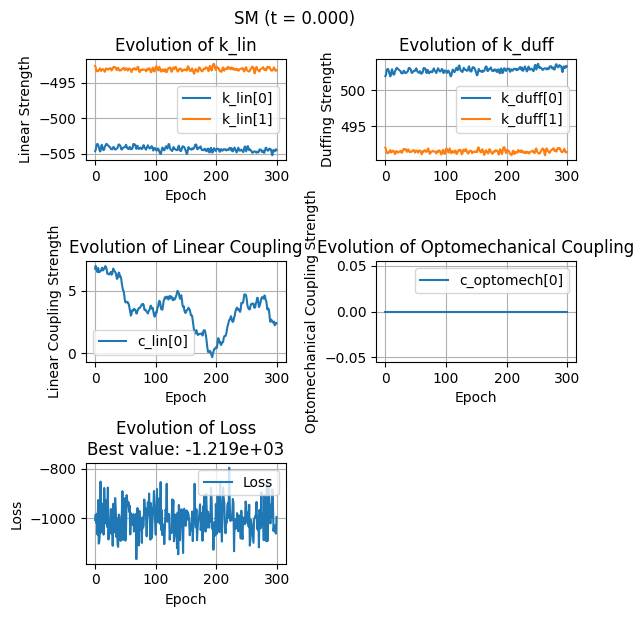

Optimization for time 1.2993087842004144e-06 with num epochs: 3000
Epoch 0
Loss: -1058.5370
---
Epoch 100
Loss: -888.4990
---
Epoch 200
Loss: -1046.4412
---
Epoch 300
Loss: -988.0885
---
Epoch 400
Loss: -1095.5962
---
Epoch 500
Loss: -1032.2914
---
Epoch 600
Loss: -1109.6673
---
Epoch 700
Loss: -956.2362
---
Epoch 800
Loss: -885.2915
---
Epoch 900
Loss: -884.3566
---
Epoch 1000
Loss: -909.8977
---
Epoch 1100
Loss: -934.7232
---
Epoch 1200
Loss: -1096.5201
---
Epoch 1300
Loss: -906.9808
---
Epoch 1400
Loss: -908.8972
---
Epoch 1500
Loss: -1080.8779
---
Epoch 1600
Loss: -974.8577
---
Epoch 1700
Loss: -920.0462
---
Epoch 1800
Loss: -1032.6938
---
Epoch 1900
Loss: -966.5498
---
Epoch 2000
Loss: -980.7801
---
Epoch 2100
Loss: -972.2798
---
Epoch 2200
Loss: -969.6697
---
Epoch 2300
Loss: -868.3294
---
Epoch 2400
Loss: -955.8489
---
Epoch 2500
Loss: -1057.0223
---
Epoch 2600
Loss: -970.5209
---
Epoch 2700
Loss: -988.5155
---
Epoch 2800
Loss: -876.1265
---
Epoch 2900
Loss: -886.9402
---
Optimi

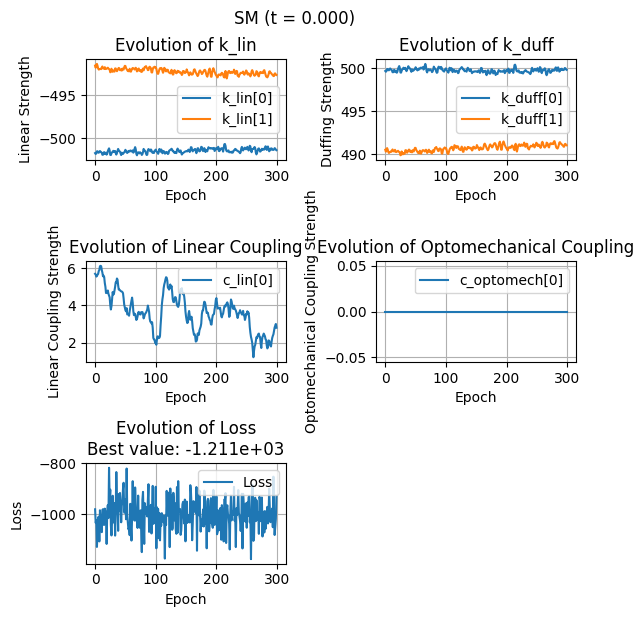

Optimization for time 6.061898993497579e-06 with num epochs: 3000
Epoch 0
Loss: -1021.8909
---
Epoch 100
Loss: -909.6915
---
Epoch 200
Loss: -995.1171
---
Epoch 300
Loss: -976.8068
---
Epoch 400
Loss: -1026.9879
---
Epoch 500
Loss: -1044.8463
---
Epoch 600
Loss: -966.0018
---
Epoch 700
Loss: -946.3984
---
Epoch 800
Loss: -1044.7934
---
Epoch 900
Loss: -1029.3155
---
Epoch 1000
Loss: -1002.2302
---
Epoch 1100
Loss: -821.8187
---
Epoch 1200
Loss: -1018.6080
---
Epoch 1300
Loss: -1028.4908
---
Epoch 1400
Loss: -985.8274
---
Epoch 1500
Loss: -971.6445
---
Epoch 1600
Loss: -866.9637
---
Epoch 1700
Loss: -1041.7416
---
Epoch 1800
Loss: -1021.9060
---
Epoch 1900
Loss: -1044.2474
---
Epoch 2000
Loss: -919.7232
---
Epoch 2100
Loss: -1006.2868
---
Epoch 2200
Loss: -1032.1327
---
Epoch 2300
Loss: -1057.6083
---
Epoch 2400
Loss: -919.7465
---
Epoch 2500
Loss: -850.6948
---
Epoch 2600
Loss: -952.2079
---
Epoch 2700
Loss: -1021.5768
---
Epoch 2800
Loss: -1103.0284
---
Epoch 2900
Loss: -955.6849
---


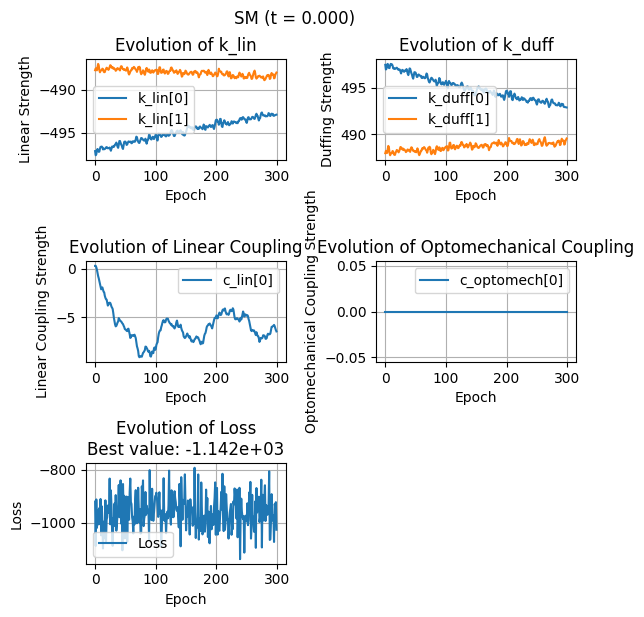

Optimization for time 2.8281667802300318e-05 with num epochs: 3000
Epoch 0
Loss: -1030.6766
---
Epoch 100
Loss: -975.3031
---
Epoch 200
Loss: -921.7439
---
Epoch 300
Loss: -969.6006
---
Epoch 400
Loss: -889.5973
---
Epoch 500
Loss: -896.5197
---
Epoch 600
Loss: -927.8790
---
Epoch 700
Loss: -1090.0498
---
Epoch 800
Loss: -941.3523
---
Epoch 900
Loss: -906.6756
---
Epoch 1000
Loss: -949.1807
---
Epoch 1100
Loss: -979.5913
---
Epoch 1200
Loss: -1011.3032
---
Epoch 1300
Loss: -873.2060
---
Epoch 1400
Loss: -948.7205
---
Epoch 1500
Loss: -923.7944
---
Epoch 1600
Loss: -923.8855
---
Epoch 1700
Loss: -975.5266
---
Epoch 1800
Loss: -944.8067
---
Epoch 1900
Loss: -969.8283
---
Epoch 2000
Loss: -920.1045
---
Epoch 2100
Loss: -918.5646
---
Epoch 2200
Loss: -1006.6345
---
Epoch 2300
Loss: -1009.2031
---
Epoch 2400
Loss: -917.6038
---
Epoch 2500
Loss: -961.6827
---
Epoch 2600
Loss: -991.9981
---
Epoch 2700
Loss: -988.8864
---
Epoch 2800
Loss: -997.7526
---
Epoch 2900
Loss: -956.1124
---
Optimizati

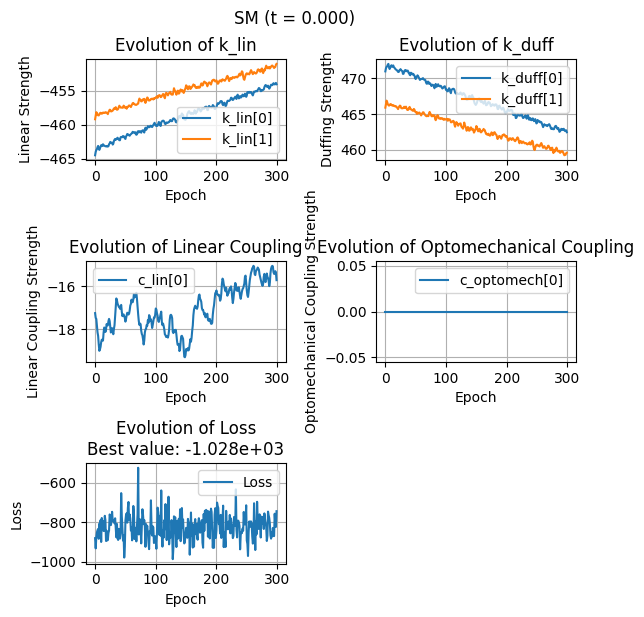

Optimization for time 0.00013194755216767062 with num epochs: 3000
Epoch 0
Loss: -792.1321
---
Epoch 100
Loss: -829.0785
---
Epoch 200
Loss: -836.1708
---
Epoch 300
Loss: -803.1271
---
Epoch 400
Loss: -776.0234
---
Epoch 500
Loss: -837.5443
---
Epoch 600
Loss: -767.8506
---
Epoch 700
Loss: -827.2414
---
Epoch 800
Loss: -721.7390
---
Epoch 900
Loss: -850.0022
---
Epoch 1000
Loss: -778.2698
---
Epoch 1100
Loss: -780.2121
---
Epoch 1200
Loss: -890.9621
---
Epoch 1300
Loss: -743.8174
---
Epoch 1400
Loss: -802.3743
---
Epoch 1500
Loss: -783.9709
---
Epoch 1600
Loss: -842.7520
---
Epoch 1700
Loss: -809.2099
---
Epoch 1800
Loss: -797.0429
---
Epoch 1900
Loss: -768.9602
---
Epoch 2000
Loss: -767.7672
---
Epoch 2100
Loss: -743.0879
---
Epoch 2200
Loss: -750.2689
---
Epoch 2300
Loss: -798.6875
---
Epoch 2400
Loss: -755.1882
---
Epoch 2500
Loss: -674.4076
---
Epoch 2600
Loss: -758.8453
---
Epoch 2700
Loss: -794.8182
---
Epoch 2800
Loss: -747.1732
---
Epoch 2900
Loss: -843.9475
---
Optimization fo

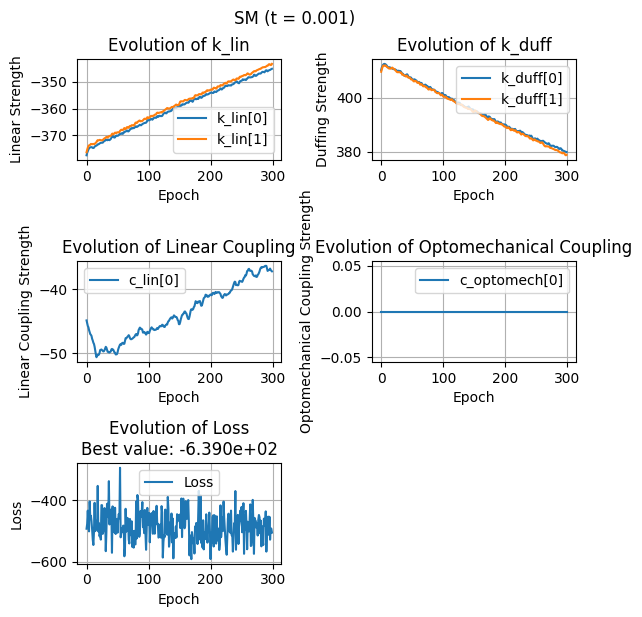

Optimization for time 0.0006155986501483506 with num epochs: 3000
Epoch 0
Loss: -449.9353
---
Epoch 100
Loss: -432.1481
---
Epoch 200
Loss: -409.1462
---
Epoch 300
Loss: -468.6553
---
Epoch 400
Loss: -435.7109
---
Epoch 500
Loss: -455.1390
---
Epoch 600
Loss: -402.5573
---
Epoch 700
Loss: -441.7541
---
Epoch 800
Loss: -292.3385
---
Epoch 900
Loss: -352.7411
---
Epoch 1000
Loss: -430.9918
---
Epoch 1100
Loss: -531.4891
---
Epoch 1200
Loss: -503.2619
---
Epoch 1300
Loss: -488.0151
---
Epoch 1400
Loss: -482.7461
---
Epoch 1500
Loss: -447.2800
---
Epoch 1600
Loss: -471.0455
---
Epoch 1700
Loss: -341.7488
---
Epoch 1800
Loss: -552.6753
---
Epoch 1900
Loss: -443.4350
---
Epoch 2000
Loss: -350.1429
---
Epoch 2100
Loss: -377.3139
---
Epoch 2200
Loss: -471.8000
---
Epoch 2300
Loss: -472.9916
---
Epoch 2400
Loss: -496.7837
---
Epoch 2500
Loss: -472.6275
---
Epoch 2600
Loss: -516.7215
---
Epoch 2700
Loss: -446.9938
---
Epoch 2800
Loss: -471.6365
---
Epoch 2900
Loss: -478.7678
---
Optimization for

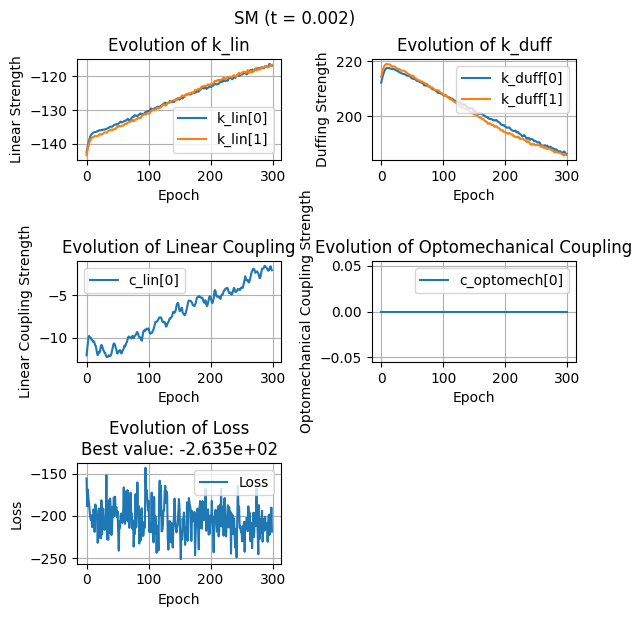

Optimization for time 0.002872063117797826 with num epochs: 3000
Epoch 0
Loss: -146.5030
---
Epoch 100
Loss: -211.9663
---
Epoch 200
Loss: -228.1624
---
Epoch 300
Loss: -214.5025
---
Epoch 400
Loss: -191.4254
---
Epoch 500
Loss: -198.7881
---
Epoch 600
Loss: -162.8805
---
Epoch 700
Loss: -162.0716
---
Epoch 800
Loss: -182.7288
---
Epoch 900
Loss: -207.8386
---
Epoch 1000
Loss: -180.5149
---
Epoch 1100
Loss: -180.6702
---
Epoch 1200
Loss: -213.1958
---
Epoch 1300
Loss: -202.0027
---
Epoch 1400
Loss: -181.5398
---
Epoch 1500
Loss: -194.1572
---
Epoch 1600
Loss: -191.2029
---
Epoch 1700
Loss: -210.3640
---
Epoch 1800
Loss: -201.1975
---
Epoch 1900
Loss: -187.9748
---
Epoch 2000
Loss: -169.2959
---
Epoch 2100
Loss: -191.4481
---
Epoch 2200
Loss: -197.9847
---
Epoch 2300
Loss: -170.6585
---
Epoch 2400
Loss: -198.5494
---
Epoch 2500
Loss: -200.3506
---
Epoch 2600
Loss: -195.1952
---
Epoch 2700
Loss: -195.1697
---
Epoch 2800
Loss: -178.1215
---
Epoch 2900
Loss: -215.0278
---
Optimization for 

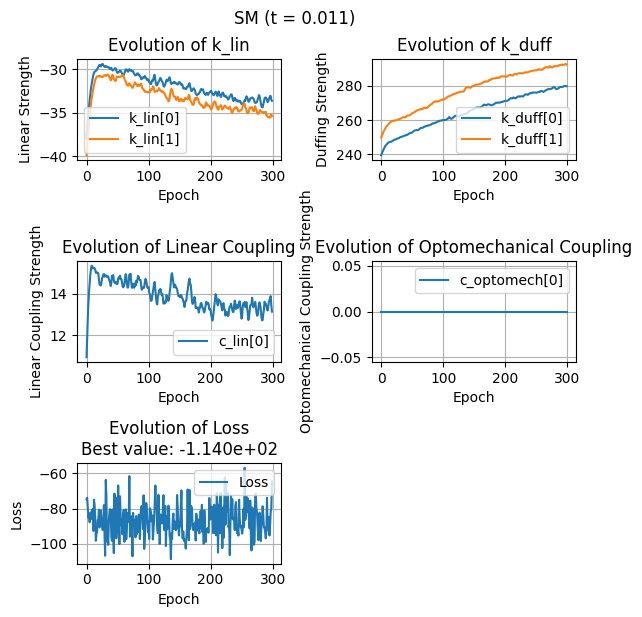

Optimization for time 0.013399552696593368 with num epochs: 3000
Epoch 0
Loss: -68.4630
---
Epoch 100
Loss: -86.0150
---
Epoch 200
Loss: -63.6058
---
Epoch 300
Loss: -73.9455
---
Epoch 400
Loss: -77.0372
---
Epoch 500
Loss: -83.8351
---
Epoch 600
Loss: -91.4543
---
Epoch 700
Loss: -78.5250
---
Epoch 800
Loss: -76.0407
---
Epoch 900
Loss: -61.7696
---
Epoch 1000
Loss: -81.3396
---
Epoch 1100
Loss: -68.6859
---
Epoch 1200
Loss: -77.9436
---
Epoch 1300
Loss: -75.3841
---
Epoch 1400
Loss: -54.3908
---
Epoch 1500
Loss: -89.2253
---
Epoch 1600
Loss: -76.2525
---
Epoch 1700
Loss: -73.6405
---
Epoch 1800
Loss: -76.0116
---
Epoch 1900
Loss: -76.8993
---
Epoch 2000
Loss: -76.1477
---
Epoch 2100
Loss: -81.7528
---
Epoch 2200
Loss: -73.0281
---
Epoch 2300
Loss: -80.1766
---
Epoch 2400
Loss: -78.0598
---
Epoch 2500
Loss: -77.0358
---
Epoch 2600
Loss: -69.6273
---
Epoch 2700
Loss: -78.3711
---
Epoch 2800
Loss: -81.0036
---
Epoch 2900
Loss: -92.9126
---
Optimization for time 0.015630754179458146 with

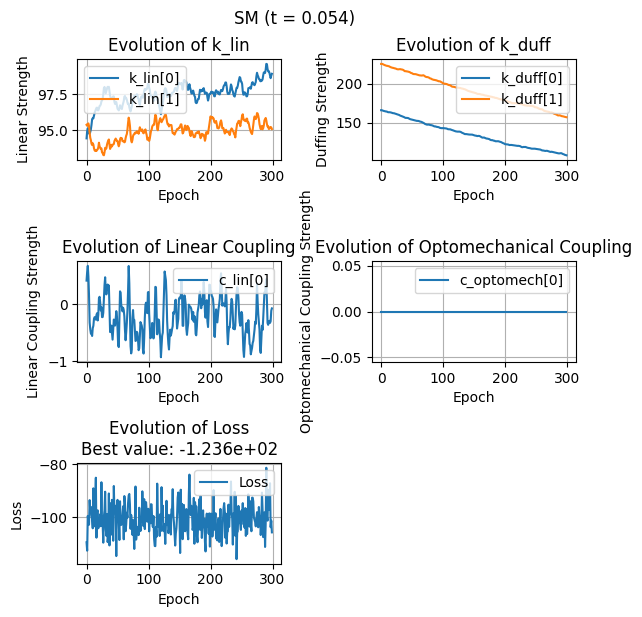

Optimization for time 0.06251534353689707 with num epochs: 3000
Epoch 0
Loss: -94.6356
---
Epoch 100
Loss: -103.0750
---
Epoch 200
Loss: -105.7469
---
Epoch 300
Loss: -103.3385
---
Epoch 400
Loss: -99.6155
---
Epoch 500
Loss: -87.1589
---
Epoch 600
Loss: -106.5560
---
Epoch 700
Loss: -99.8397
---
Epoch 800
Loss: -103.6723
---
Epoch 900
Loss: -101.5414
---
Epoch 1000
Loss: -99.3860
---
Epoch 1100
Loss: -92.2860
---
Epoch 1200
Loss: -105.5443
---
Epoch 1300
Loss: -110.4930
---
Epoch 1400
Loss: -103.3491
---
Epoch 1500
Loss: -93.5558
---
Epoch 1600
Loss: -96.7341
---
Epoch 1700
Loss: -97.9124
---
Epoch 1800
Loss: -101.2925
---
Epoch 1900
Loss: -102.1710
---
Epoch 2000
Loss: -92.6597
---
Epoch 2100
Loss: -111.5253
---
Epoch 2200
Loss: -111.7953
---
Epoch 2300
Loss: -96.5197
---
Epoch 2400
Loss: -102.4620
---
Epoch 2500
Loss: -107.5358
---
Epoch 2600
Loss: -86.3035
---
Epoch 2700
Loss: -100.7333
---
Epoch 2800
Loss: -116.1719
---
Epoch 2900
Loss: -99.7806
---
Optimization for time 0.0729249

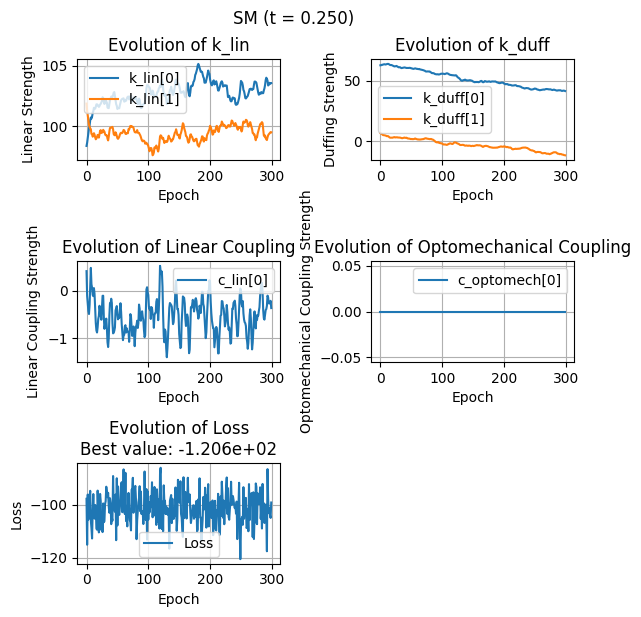

Optimization for time 0.29166407760237023 with num epochs: 3000
Epoch 0
Loss: -103.9866
---
Epoch 100
Loss: -110.8396
---
Epoch 200
Loss: -93.0645
---
Epoch 300
Loss: -100.4225
---
Epoch 400
Loss: -91.2821
---
Epoch 500
Loss: -110.7830
---
Epoch 600
Loss: -81.4387
---
Epoch 700
Loss: -96.6371
---
Epoch 800
Loss: -101.4521
---
Epoch 900
Loss: -109.4618
---
Epoch 1000
Loss: -107.2998
---
Epoch 1100
Loss: -92.5041
---
Epoch 1200
Loss: -102.6207
---
Epoch 1300
Loss: -107.7969
---
Epoch 1400
Loss: -100.1141
---
Epoch 1500
Loss: -85.4633
---
Epoch 1600
Loss: -86.3949
---
Epoch 1700
Loss: -111.3590
---
Epoch 1800
Loss: -107.0879
---
Epoch 1900
Loss: -95.3940
---
Epoch 2000
Loss: -96.8182
---
Epoch 2100
Loss: -102.5971
---
Epoch 2200
Loss: -98.9073
---
Epoch 2300
Loss: -105.6899
---
Epoch 2400
Loss: -99.8695
---
Epoch 2500
Loss: -91.9925
---
Epoch 2600
Loss: -91.3265
---
Epoch 2700
Loss: -96.9051
---
Epoch 2800
Loss: -92.2373
---
Epoch 2900
Loss: -103.3803
---
Optimization for time 0.340229976

In [13]:
load_param_histories = False
filename = f"out/parameter_histories/{training_method}/params_history_means_{means.flatten()}_covs_{covs.flatten()}_weights_{weights}_t_forward_{t_forward}_n_timestes_{n_time_steps}.npy"
if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(filename)
else:
    # Setup optimization parameters
    mask = jnp.ones(flattened_args_initial.shape[0])
    # mask = mask.at[0].set(1.)
    # mask = mask.at[1].set(1.)
    mask = mask.at[-1].set(0.0)
    learning_rate = 0.1
    n_epochs_start = 100000//2
    n_epochs_after_start = 3000
    batch_size = 2*128

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = flattened_args_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print
        if t_idx == 0: 
            n_epochs = n_epochs_start
        else:
            n_epochs = n_epochs_after_start
        print(f"Optimization for time {t_curr} with num epochs: {n_epochs}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_curr, n_samples, D=1, sigma_final=sigma_final, samples0=samples_0, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize
        )
        
        _, best_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        k_lin_best, k_duff_best, c_lin_best, c_optomech_best = unflatten(best_params)
        current_params, _ = flatten_util.ravel_pytree(best_params)
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize
                )
                # Plot current energy landscape
                # plot_energy_and_distributions(
                #     energy_fn=energy_fn,
                #     param_list=[current_params],
                #     samples=samples_t,
                #     x1_range=(-1, 1),
                #     x2_range=(-1, 1),
                #     n_points=30,
                #     titles=[f"t = {t_forward:.3f}"],
                #     fontsize=16,
                #     sample_stride=1,
                #     suptitle=f"Energy Landscape at t = {t_forward:.3f}"
                # )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    # jnp.save(filename, params_history_all_t)


### Smoothen and interpolate parameter evolution

In [14]:
def smooth_parameters(params, window_lengths = [31, 31, 31, 31, 31, 31], poly_orders = [3, 3, 3, 3, 3, 3]):
    """
    Smooths multiple parameter trajectories using Savitzky-Golay filter
    
    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories
        window_lengths: List/array of window lengths for each parameter dimension
        poly_orders: List/array of polynomial orders for each parameter dimension
    
    Returns:
        Array of shape (n_timesteps, n_params) containing smoothed parameter trajectories
    """
    n_params = params.shape[1]
    smoothed = []
    
    for i in range(n_params):
        # Ensure window length is odd and valid
        window_length = min(window_lengths[i], len(params) - (1 - len(params) % 2))
        if window_length % 2 == 0:
            window_length -= 1
            
        # Smooth using Savitzky-Golay filter
        smoothed.append(savgol_filter(params[:, i], window_length, poly_orders[i]))
    
    return jnp.column_stack(smoothed)


def interpolate_parameters(params, time_points):
    """
    Interpolates parameter trajectories using jnp.interp in a vectorized fashion.

    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories.
        time_points: 1D array of shape (n_timesteps,) corresponding to the time points.

    Returns:
        A function that takes time points `t` (scalar or 1D array) and returns
        the interpolated parameters. For scalar `t`, the result is shape (n_params,);
        for vector `t`, the result is shape (len(t), n_params).
    """
    
    def _interpolator(t):
        # Transpose params to shape (n_params, n_timesteps) so that each row is a trajectory.
        # Use vmap to apply jnp.interp over each parameter trajectory.
        interpolated = jax.vmap(lambda param: jnp.interp(t, time_points, param))(params.T)
        # If t is an array, jnp.interp returns an array for each parameter, resulting in a
        # (n_params, len(t)) array. Transpose it so that each row corresponds to a time point.
        if jnp.ndim(t) > 0:
            return interpolated.T
        return interpolated

    return _interpolator


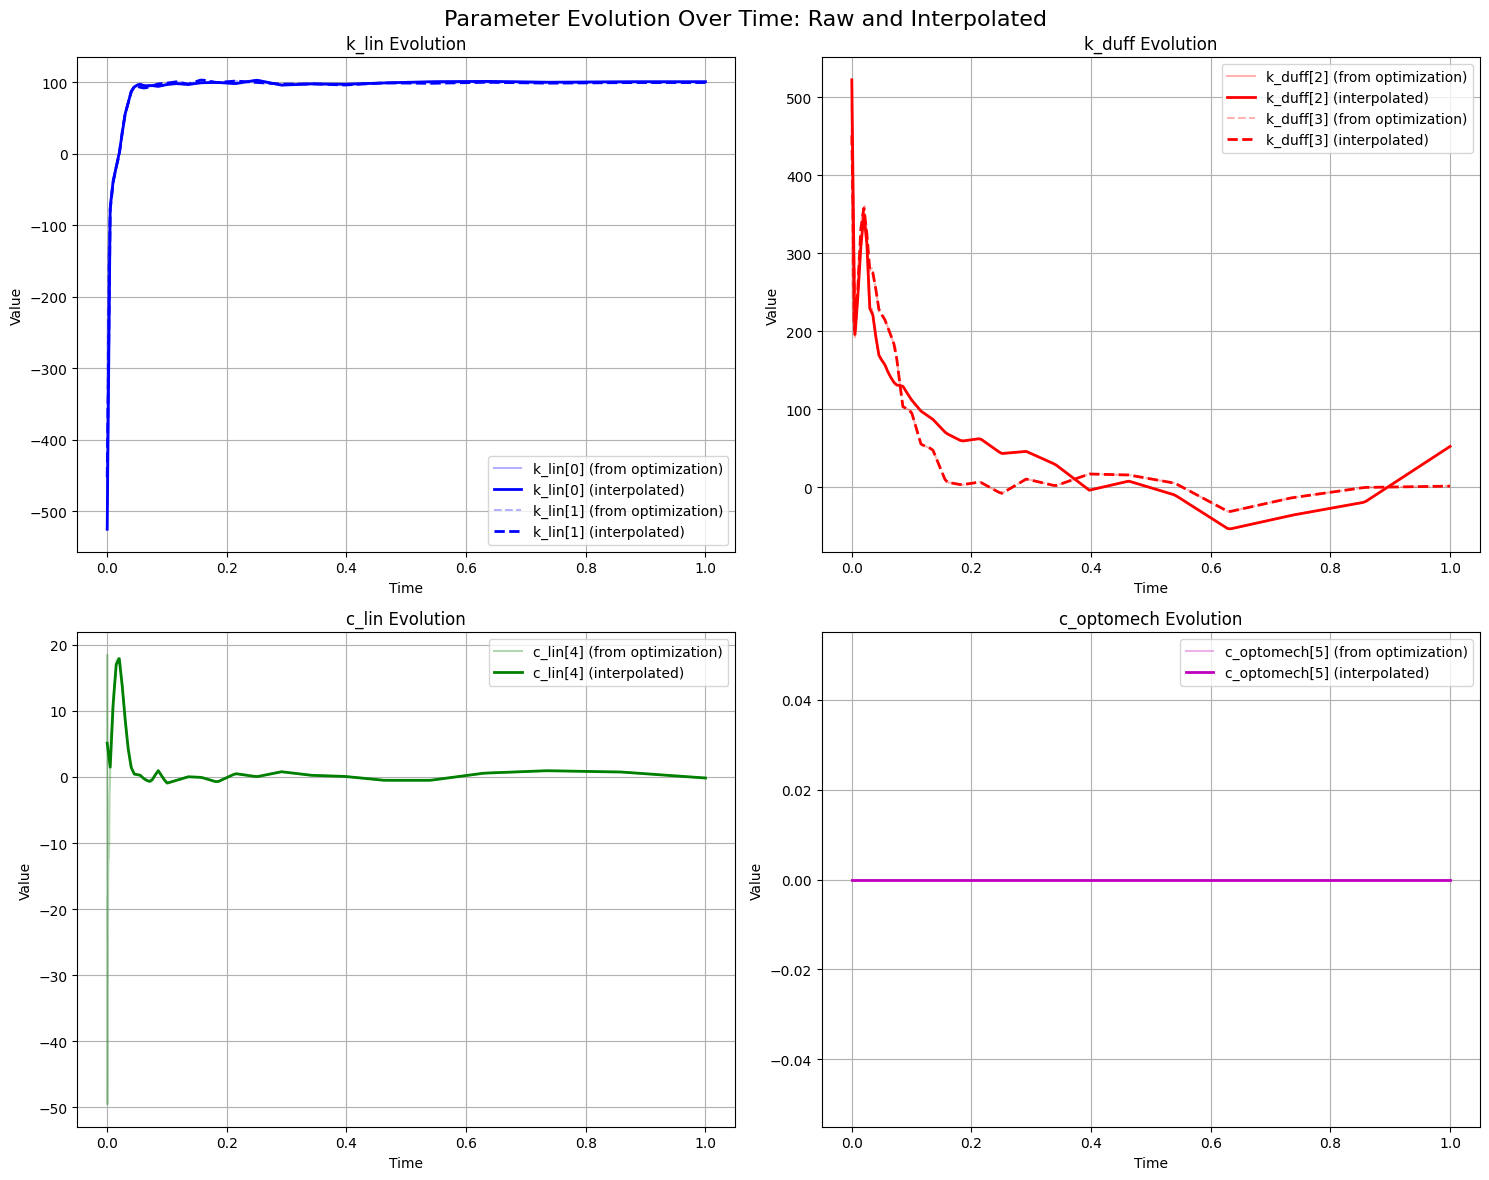

In [15]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t)
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Raw and Interpolated', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        # Plot raw data
        ax.plot(forward_time_pts, params_history_all_t[:, idx], color + style, alpha=0.3, 
                label=f'{param_name}[{idx}] (from optimization)')
        
        # Plot interpolated data
        ax.plot(time_eval, interpolated_params[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}] (interpolated)')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Run reverse SDE:

In [16]:
forward_params = jnp.zeros_like(flattened_args_initial)
forward_params = forward_params.at[0].set(1.)
forward_params = forward_params.at[1].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_final**2 * forward_params

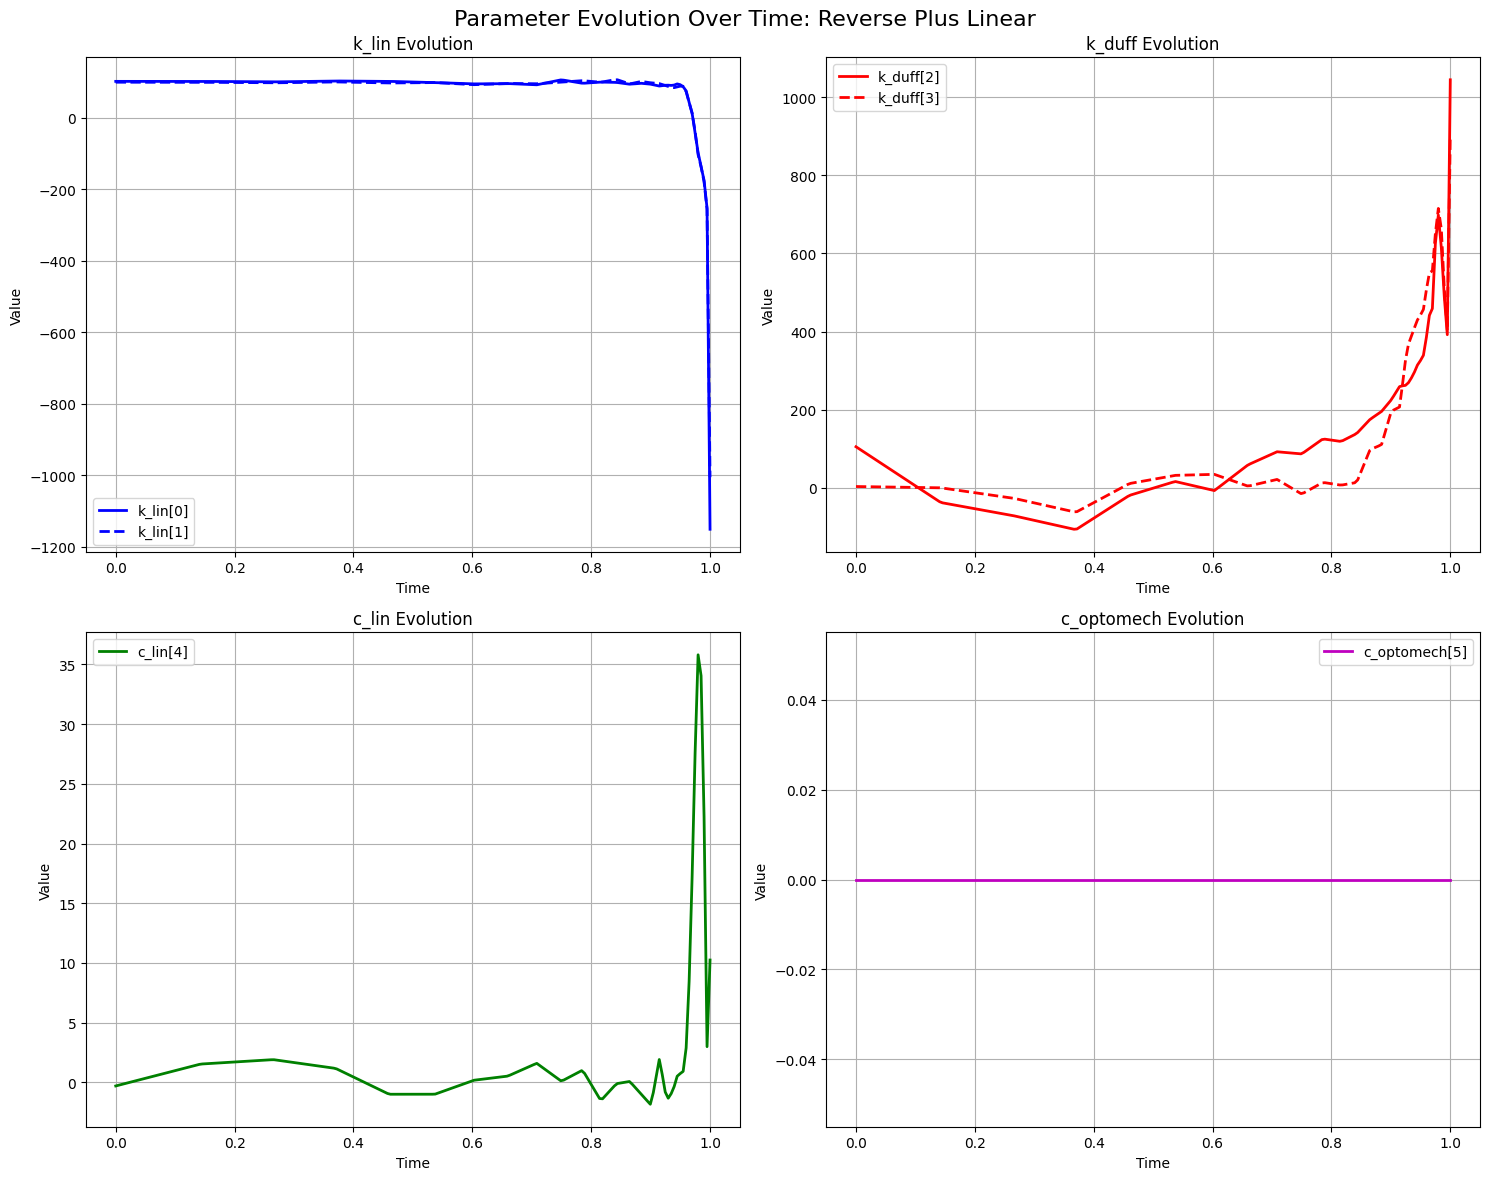

In [17]:
# Create time points for evaluation
time_eval = jnp.linspace(0, t_forward, 200)

# Get parameters at each time point
params_over_time = jnp.vstack([params_interpolator_reverse_plus_linear(t) for t in time_eval])

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Reverse Plus Linear', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        ax.plot(time_eval, params_over_time[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}]')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

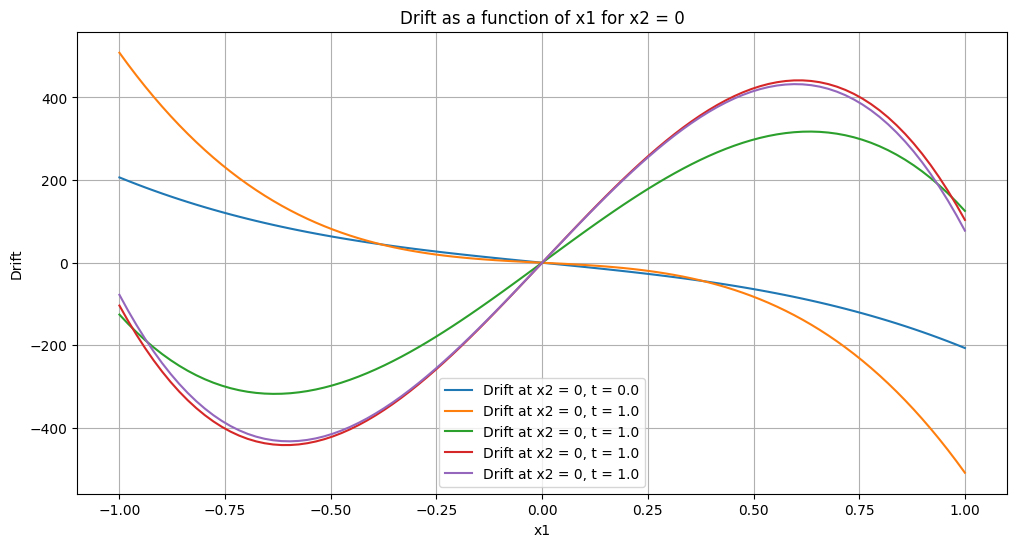

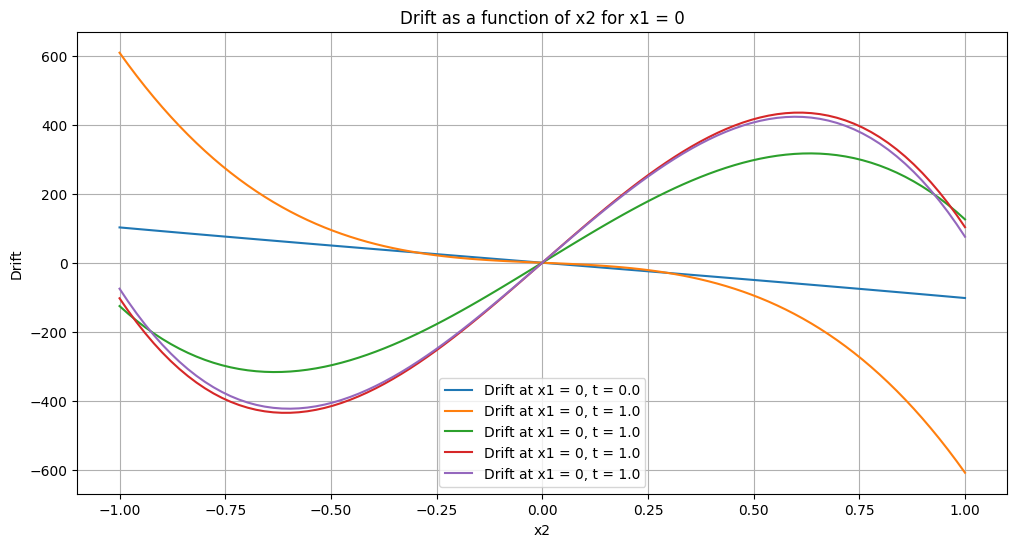

In [19]:
# Assuming drift_fn is already defined and takes (time, state, args) as input
# Define the range for x1 and x2
x_range = jnp.linspace(-1, 1, 100)  # Example range from -5 to 5

# Define filename for saving/loading parameters
n_time_steps = 5
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
time_steps = t_forward - jnp.exp(jnp.linspace(jnp.log(t_forward), jnp.log(1e-6), n_time_steps))


# Plot drift as a function of x1 for x2 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x1 = [drift_fn(t, jnp.array([x1, 0]), args=())[0] for x1 in x_range]
    plt.plot(x_range, drift_x1, label=f'Drift at x2 = 0, t = {t:.1f}')

plt.xlabel('x1')
plt.ylabel('Drift')
plt.title('Drift as a function of x1 for x2 = 0')
plt.legend()
plt.grid(True)
plt.show()

# Plot drift as a function of x2 for x1 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x2 = [drift_fn(t, jnp.array([0, x2]), args=())[1] for x2 in x_range]
    plt.plot(x_range, drift_x2, label=f'Drift at x1 = 0, t = {t:.1f}')

plt.xlabel('x2')
plt.ylabel('Drift')
plt.title('Drift as a function of x2 for x1 = 0')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 10)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
# n_trajectories = 2000
# key, subkey = jr.split(key)
# initial_states = sample_forward_process(t_forward, n_trajectories, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate)
# Sample initial conditions from N(0, I)
n_trajectories = 1000  # or any other number of trajectories you need
n_dimensions = 2  # assuming 2D, adjust as necessary
key, subkey = jr.split(key)
initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

In [22]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.0,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

Solution from reverse process probability distribution total (should be ≈ 1): 1.000000


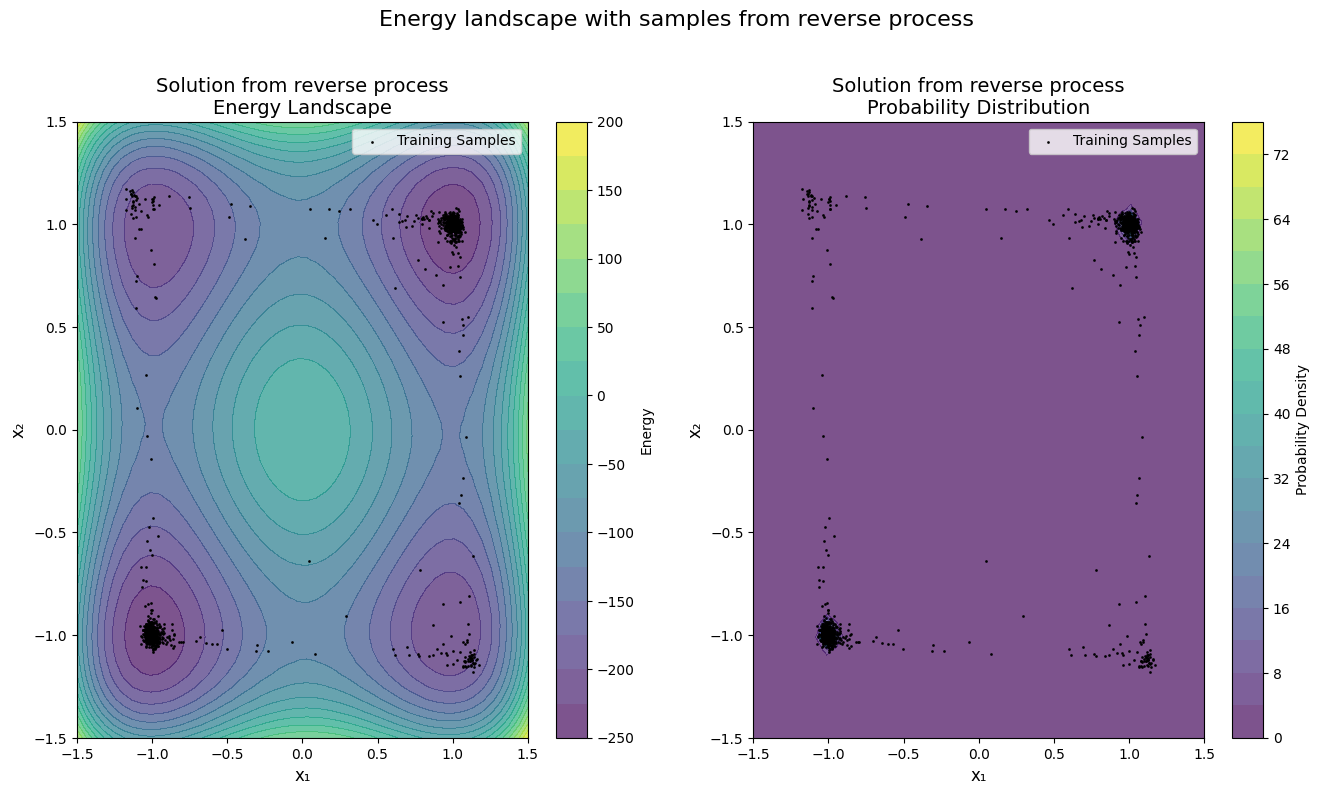

In [23]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

Solution from direct integration probability distribution total (should be ≈ 1): 1.000000


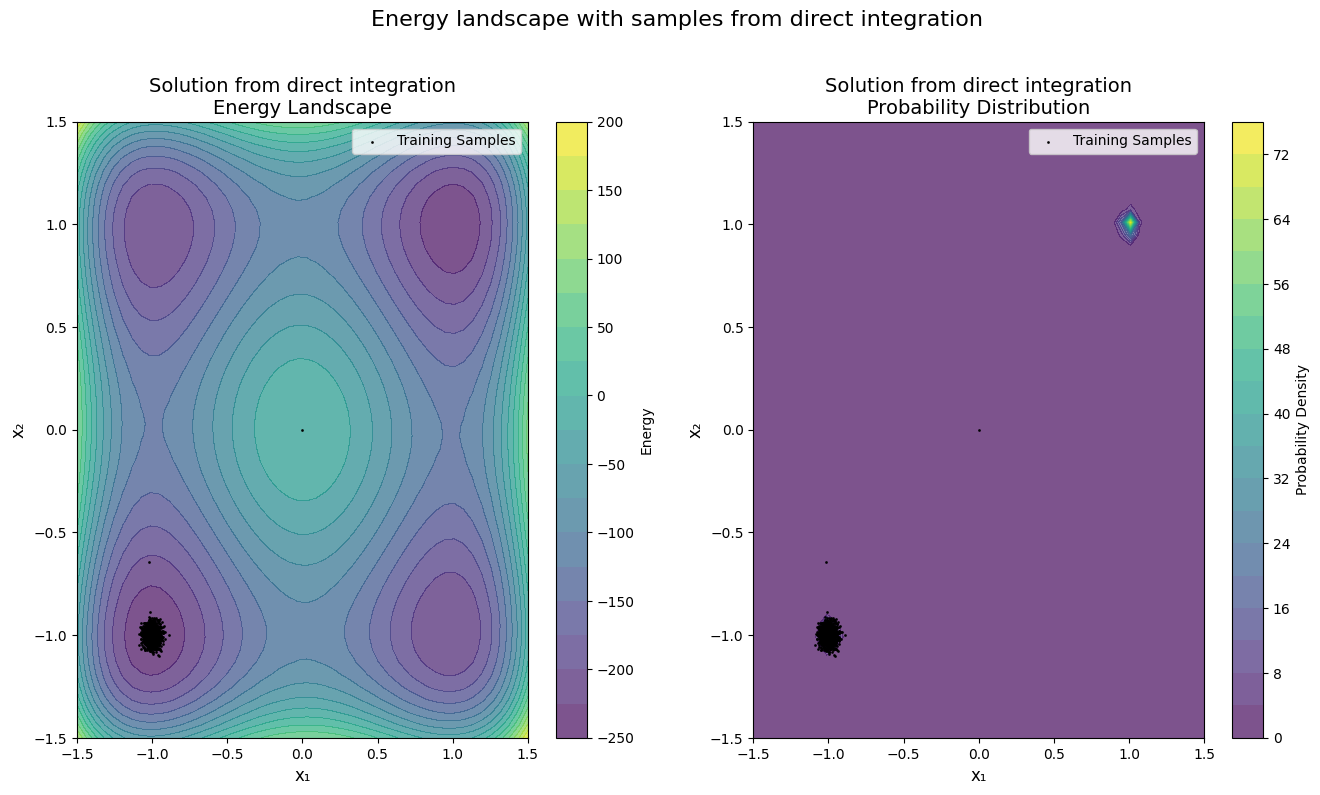

In [24]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

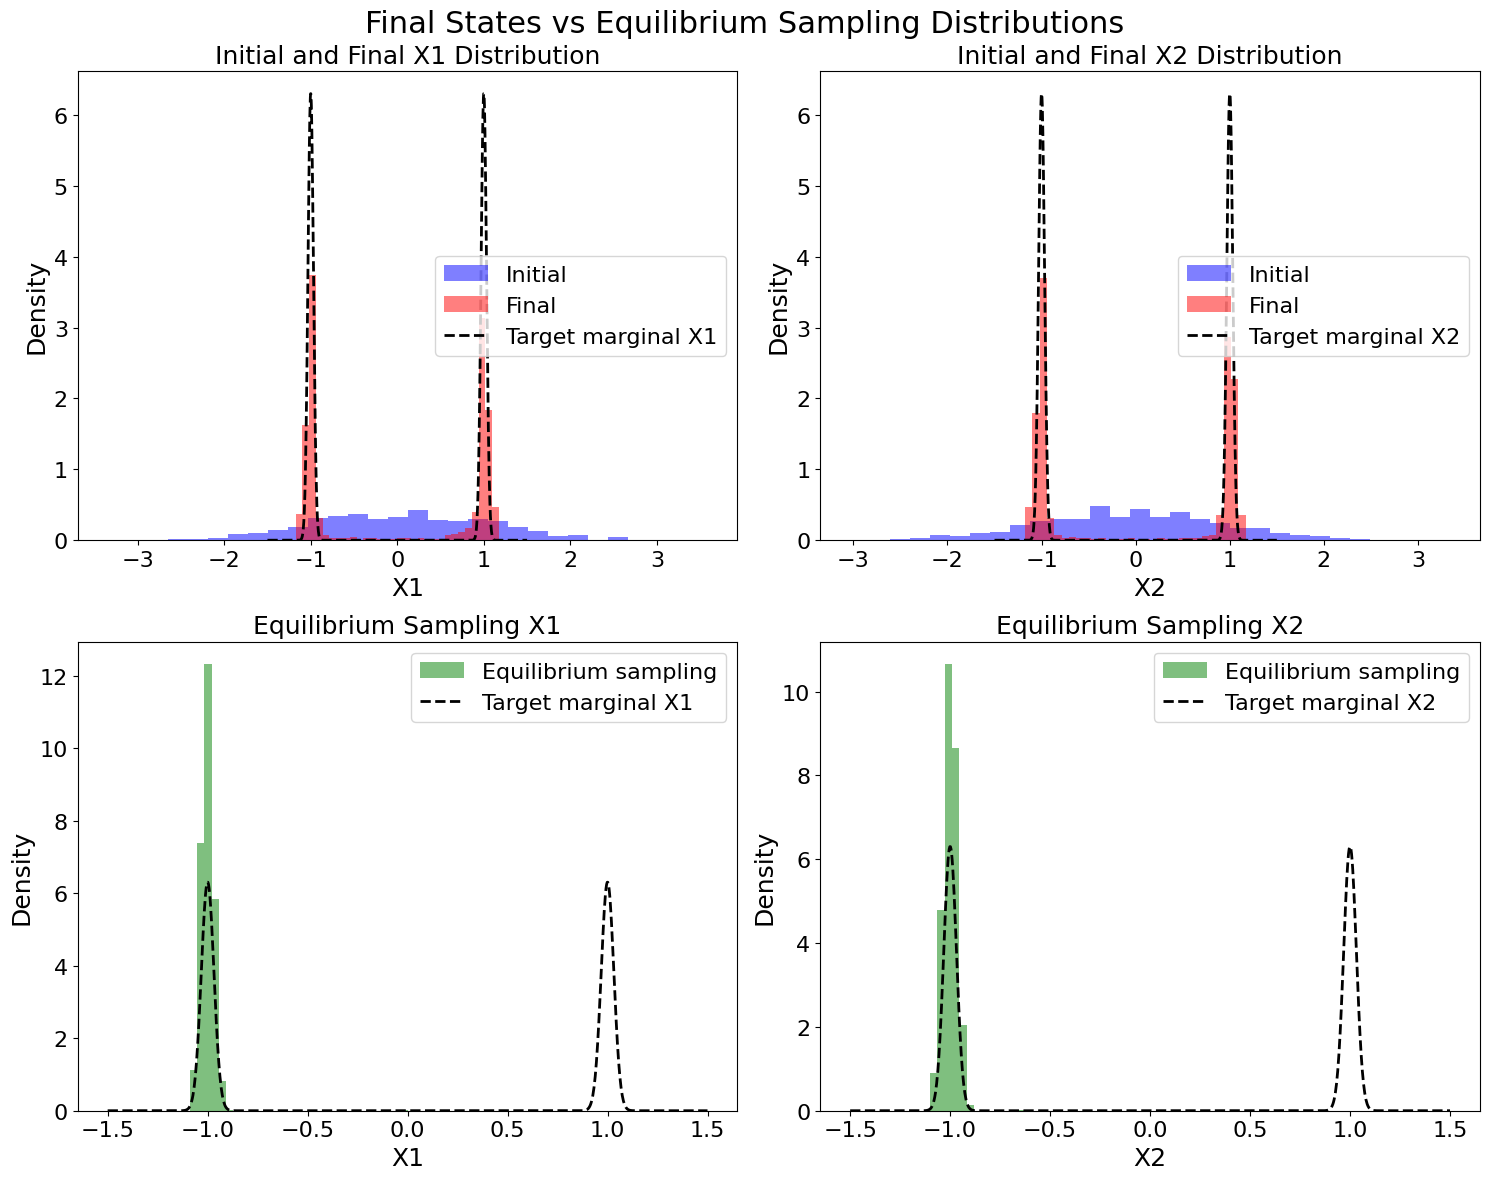

In [25]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()